# AI-Driven Detection of Misclassified Imports
## A Machine Learning and LangChain-Based RAG Approach for Customs Fraud

**Authors:** Aya Ismaili, Adnane El Amrani, Yousra Chtouki, Hind Lamharhar

---

This notebook is the **complete, consolidated implementation** of the customs fraud detection system described in the paper.  
All code is extracted and unified from the original project notebooks and scripts.

### Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | Environment Setup | Install dependencies, imports, path configuration |
| 2 | Data Inventory | Verify all project files exist and are accessible |
| 3 | HS Code Cleaning Pipeline | Normalize HS nomenclature, build ontology and RAG corpus |
| 4 | Exploratory Data Analysis (HS) | Visualize HS code structure, risk categories, chapter distribution |
| 5 | Synthetic Data Generation | Algorithm 1: 1M declarations with 4 fraud mechanisms |
| 6 | Dataset EDA | Fraud distribution, feature correlations, outlier analysis |
| 7 | Feature Engineering | Numerical, categorical, text feature pipelines |
| 8 | Train/Val/Test Split | Stratified splitting (800K/50K/150K) |
| 9 | XGBoost Classifier | Training with paper hyperparameters |
| 10 | XGBoost Evaluation | Threshold tuning, test metrics, confusion matrix |
| 11 | Random Forest Baseline | Training and evaluation |
| 12 | Logistic Regression Baseline | Training and evaluation |
| 13 | XGBoost Structured-Only | Ablation: no text features |
| 14 | Model Comparison — Table I | All classifiers side-by-side |
| 15 | Precision-Recall Curves | Visual comparison of all models |
| 16 | Ablation Studies — Table IV | Systematic feature removal analysis |
| 17 | Feature Importance Analysis | Top features driving fraud detection |
| 18 | FAISS Index Construction | Build semantic index over HS codes |
| 19 | RAG Agent 1 — HS Code Prediction | Retrieval + LLM classification |
| 20 | Agent 1 Accuracy — Table III | HS code prediction accuracy evaluation |
| 21 | Legal Document Chunking | Process customs_rules.pdf for Agent 2 |
| 22 | RAG Agent 2 — Explanation Generation | Legal-grounded fraud explanations |
| 23 | LangChain Agent 2 Pipeline | Full LangChain implementation |
| 24 | Load Existing Agent Outputs | Display pre-computed RAG results |
| 25 | Bootstrap Confidence Intervals | 95% CI via 1000 bootstrap resamples |
| 26 | McNemar's Statistical Test | Pairwise classifier significance testing |
| 27 | Computational Efficiency | Inference timing benchmarks |
| 28 | Cost Efficiency Analysis | Hybrid vs pure LLM cost comparison |
| 29 | Error Analysis | False negatives and false positives breakdown |
| 30 | Explanation Quality — Table V | Expert assessment reference results |
| 31 | Real Data System Demo | End-to-end prediction on real transaction format |
| 32 | Save All Results | Export models, metrics, and experiment log |

### Source Files Consolidated

**Notebooks** (`fraud_detection/notebooks/`):
- `01_hs_cleaning_pipeline.ipynb` — HS nomenclature processing
- `clean_dataset_gen.ipynb` — Synthetic 1M dataset generation
- `train_xgboost_classifier.ipynb` — XGBoost training pipeline
- `Random_forest.ipynb` — Random Forest baseline
- `rag_pipeline.ipynb` — RAG Agent 1 + Agent 2 + LangChain

**Scripts** (`Fraud_detection_system/`):
- `generate_the_data.py`, `XGboost.py`, `randomforest.py`
- `detection_agent.py`, `fraud_explanation_agent.py`, `prediction_for_agent.py`
- `load_chunk.py`, `ragchat.py`, `customs_fraud_detection_system.py`

---

## 1. Environment Setup & Imports

In [149]:
# ============================================================
# 1.1 Install required packages (uncomment lines as needed)
# ============================================================
# !pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib
# !pip install -q imbalanced-learn
# !pip install -q faiss-cpu sentence-transformers
# !pip install -q langchain langchain-community langchain-core
# !pip install -q openai pdfminer.six
# !pip install -q scikit-optimize

In [150]:
# ============================================================
# 1.2 Core imports
# ============================================================
import os
import re
import json
import time
import joblib
import pickle
import random
import unicodedata
import warnings
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, fbeta_score, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import hstack
from scipy.stats import chi2

import xgboost as xgb

warnings.filterwarnings('ignore')
# Compatibility patch: _RemainderColsList was removed in sklearn >= 1.7
# but is needed to load pipelines saved with sklearn 1.6.x
import sklearn.compose._column_transformer as _ct_module
if not hasattr(_ct_module, '_RemainderColsList'):
    class _RemainderColsList(list):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.future_dtype = None
    _ct_module._RemainderColsList = _RemainderColsList
    print("[PATCH] Added _RemainderColsList for sklearn 1.6.x pipeline compatibility")

pd.set_option('display.max_colwidth', 120)
sns.set_style('whitegrid')

# Optional imports with graceful fallback
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("[WARN] imbalanced-learn not installed. SMOTE will be skipped.")

try:
    from sentence_transformers import SentenceTransformer
    import faiss
    RAG_AVAILABLE = True
except ImportError:
    RAG_AVAILABLE = False
    print("[WARN] sentence-transformers / faiss-cpu not installed. RAG sections will be skipped.")

try:
    from openai import OpenAI
    OPENAI_AVAILABLE = True
except ImportError:
    OPENAI_AVAILABLE = False
    print("[WARN] openai not installed. LLM API calls will use mock responses.")

try:
    from langchain_community.embeddings import SentenceTransformerEmbeddings
    from langchain_community.vectorstores import FAISS as LangchainFAISS
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.output_parsers import StrOutputParser
    LANGCHAIN_AVAILABLE = True
except ImportError:
    LANGCHAIN_AVAILABLE = False
    print("[WARN] langchain not installed. LangChain Agent 2 will be skipped.")

try:
    from pdfminer.high_level import extract_text as pdf_extract_text
    PDFMINER_AVAILABLE = True
except ImportError:
    PDFMINER_AVAILABLE = False
    print("[WARN] pdfminer.six not installed. PDF extraction will be skipped.")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"Python packages loaded successfully.")
print(f"  NumPy:     {np.__version__}")
print(f"  Pandas:    {pd.__version__}")
print(f"  XGBoost:   {xgb.__version__}")
print(f"  RAG ready: {RAG_AVAILABLE}")
print(f"  LangChain: {LANGCHAIN_AVAILABLE}")
print(f"  PDF miner: {PDFMINER_AVAILABLE}")

Python packages loaded successfully.
  NumPy:     2.2.6
  Pandas:    2.3.3
  XGBoost:   2.1.4
  RAG ready: True
  LangChain: True
  PDF miner: True


In [151]:
# ============================================================
# 1.3 Project directory configuration — ALL datasets and models
# ============================================================
# Primary project (notebooks + large 1M dataset)
PROJECT_ROOT = r"C:\Users\Administrator\Desktop\fraud_detection"
DATA_DIR     = os.path.join(PROJECT_ROOT, "data")
MODEL_DIR    = os.path.join(PROJECT_ROOT, "models")
OUTPUT_DIR   = os.path.join(PROJECT_ROOT, "outputs")
RAG_DIR      = os.path.join(PROJECT_ROOT, "hs_rag_index")
NOTEBOOK_DIR = os.path.join(PROJECT_ROOT, "notebooks")

# Secondary project (standalone scripts + 5K dataset)
ALT_ROOT     = r"C:\Users\Administrator\Desktop\Fraud_detection_system"
ALT_SCRIPTS  = os.path.join(ALT_ROOT, "Fraud_detection_system")

for d in [DATA_DIR, MODEL_DIR, OUTPUT_DIR, RAG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Primary dataset files ──
HS_ENRICHED_CSV      = os.path.join(DATA_DIR, "base_SH_enriched.csv")
TRANSACTIONS_CSV     = os.path.join(DATA_DIR, "customs_transactions.csv")
CUSTOMS_RULES_PDF    = os.path.join(DATA_DIR, "customs_rules.pdf")

# ── Primary output files ──
ONTOLOGY_CSV         = os.path.join(OUTPUT_DIR, "hs_ontology.csv")
HS_ML_TABLE_CSV      = os.path.join(OUTPUT_DIR, "hs_ml_table.csv")
RAG_CORPUS_JSONL     = os.path.join(OUTPUT_DIR, "hs_rag_corpus.jsonl")
RAG_SAMPLE_CSV       = os.path.join(OUTPUT_DIR, "rag_fraud_detection_sample.csv")
AGENT2_LEGAL_CSV     = os.path.join(OUTPUT_DIR, "agent2_legal_explanations.csv")
AGENT2_LANGCHAIN_CSV = os.path.join(OUTPUT_DIR, "agent2_langchain_explanations.csv")
AGENT2_LC_XLSX       = os.path.join(OUTPUT_DIR, "agent2_langchain_explanations.xlsx")

# ── Primary trained models ──
XGB_MODEL_PATH       = os.path.join(MODEL_DIR, "xgb_fraud_model_trained.joblib")
XGB_MODEL_SMALL_PATH = os.path.join(MODEL_DIR, "xgb_fraud_model.joblib")
RF_MODEL_PATH        = os.path.join(MODEL_DIR, "rf_fraud_model.joblib")
TAB_PIPELINE_PATH    = os.path.join(MODEL_DIR, "tabular_pipeline.joblib")
TAB_PIPELINE_RF_PATH = os.path.join(MODEL_DIR, "tabular_pipeline_rf.joblib")
TEXT_VEC_PATH        = os.path.join(MODEL_DIR, "text_vectorizer.joblib")
TEXT_VEC_RF_PATH     = os.path.join(MODEL_DIR, "text_vectorizer_rf.joblib")

# ── Primary RAG index ──
FAISS_INDEX_PATH     = os.path.join(RAG_DIR, "hs_index.faiss")
FAISS_META_PATH      = os.path.join(RAG_DIR, "hs_metadata.pkl")
FAISS_ENC_PATH       = os.path.join(RAG_DIR, "hs_encoder_name.pkl")

# ── Alternative project files (Fraud_detection_system) ──
ALT_DATASET_CSV      = os.path.join(ALT_SCRIPTS, "fraud_detection_dataset_realistic.csv")
ALT_RESULTS_CSV      = os.path.join(ALT_ROOT, "fraud_detection_results.csv")
ALT_TX_CHECK_CSV     = os.path.join(ALT_SCRIPTS, "transactions_to_check.csv")
ALT_XGB_PKL          = os.path.join(ALT_SCRIPTS, "fraud_detection_xgboost_final.pkl")
ALT_XGB_SIMPLE_PKL   = os.path.join(ALT_SCRIPTS, "fraud_detection_xgboost_final_simple.pkl")
ALT_XGB_FINAL_PKL    = os.path.join(ALT_SCRIPTS, "xgboost_final.pkl")
ALT_RF_PKL           = os.path.join(ALT_SCRIPTS, "fraud_detection_randomforest_smote.pkl")
ALT_FAISS_DIR        = os.path.join(ALT_SCRIPTS, "fraud_regulations_index")
ALT_FAISS_INDEX      = os.path.join(ALT_FAISS_DIR, "index.faiss")
ALT_FAISS_META       = os.path.join(ALT_FAISS_DIR, "index.pkl")
ALT_LEGAL_PDF        = os.path.join(ALT_SCRIPTS, "20-val.pdf")

# ── Fraud explanation TXT files (679 files generated by Agent 2) ──
FRAUD_EXPLANATIONS_DIR = ALT_ROOT   # fraud_explanation_TX*.txt files
FRAUD_REPORT_TXT     = os.path.join(ALT_ROOT, "fraud_detection_report.txt")

print("All project paths configured.")
print(f"Primary project: {PROJECT_ROOT}")
print(f"Alt project:     {ALT_ROOT}")

All project paths configured.
Primary project: C:\Users\Administrator\Desktop\fraud_detection
Alt project:     C:\Users\Administrator\Desktop\Fraud_detection_system


In [152]:
# ============================================================
# 1.4 Reusable utility class
# ============================================================
class ColumnSelector(BaseEstimator, TransformerMixin):
    """Select specific columns from a DataFrame for use in sklearn Pipelines."""
    def __init__(self, columns):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.columns]

print("Utility class ColumnSelector defined.")

Utility class ColumnSelector defined.


---
## 1.5 Load Pre-Trained Models & Artifacts

Load all **existing trained models**, pipelines, and indexes from the project directories.
This avoids retraining from scratch and ensures we use the exact artifacts that produced the paper results.

> **Note:** The `ColumnSelector` class must be defined (cell above) before loading `tabular_pipeline.joblib`.

In [153]:
# ============================================================
# 1.5.1 Load ALL pre-trained models from both projects
# ============================================================
pretrained_models = {}

# ── Primary project models (fraud_detection/models/) ──
for key, path, label in [
    ("xgb",      XGB_MODEL_PATH,       "XGBoost (trained, n_est=600, depth=6)"),
    ("rf",       RF_MODEL_PATH,        "Random Forest (n_est=150, depth=12)"),
    ("pipeline", TAB_PIPELINE_PATH,    "Tabular Pipeline (StandardScaler + OneHot)"),
    ("tfidf",    TEXT_VEC_PATH,        "TF-IDF Vectorizer (max_features=8000)"),
    ("pipeline_rf", TAB_PIPELINE_RF_PATH, "Tabular Pipeline (RF version)"),
    ("tfidf_rf",    TEXT_VEC_RF_PATH,     "TF-IDF Vectorizer (RF version)"),
]:
    if os.path.exists(path):
        try:
            pretrained_models[key] = joblib.load(path)
            print(f"  [OK] {label}: {os.path.basename(path)}")
        except Exception as e:
            print(f"  [FAIL] {label}: {e}")
    else:
        print(f"  [--] {label}: not found")

# ── Alt project models (Fraud_detection_system/) ──
alt_models = {}
for key, path, label in [
    ("alt_xgb_dict",  ALT_XGB_PKL,        "Alt XGBoost (full system dict)"),
    ("alt_xgb_simple", ALT_XGB_SIMPLE_PKL, "Alt XGBoost (simple)"),
    ("alt_rf",        ALT_RF_PKL,          "Alt RF (SMOTE)"),
]:
    if os.path.exists(path):
        try:
            alt_models[key] = joblib.load(path)
            print(f"  [OK] {label}: {os.path.basename(path)}")
        except Exception as e:
            print(f"  [FAIL] {label}: {e}")

# Extract XGBClassifier from alt_xgb dict (it contains the full system)
if "alt_xgb_dict" in alt_models and isinstance(alt_models["alt_xgb_dict"], dict):
    d = alt_models["alt_xgb_dict"]
    print(f"\n  Alt XGBoost dict keys: {list(d.keys())}")
    if "xgboost_model" in d:
        alt_models["alt_xgb"] = d["xgboost_model"]
        print(f"  [OK] Extracted XGBClassifier from dict -> alt_models['alt_xgb']")
    if "preprocessor" in d:
        alt_models["alt_preprocessor"] = d["preprocessor"]
    if "tfidf_vectorizer" in d:
        alt_models["alt_tfidf"] = d["tfidf_vectorizer"]
    if "hs_code_descriptions" in d:
        alt_models["alt_hs_descriptions"] = d["hs_code_descriptions"]

print(f"\nPrimary models loaded: {list(pretrained_models.keys())}")
print(f"Alt models loaded:     {list(alt_models.keys())}")

  [OK] XGBoost (trained, n_est=600, depth=6): xgb_fraud_model_trained.joblib
  [OK] Random Forest (n_est=150, depth=12): rf_fraud_model.joblib
  [OK] Tabular Pipeline (StandardScaler + OneHot): tabular_pipeline.joblib
  [OK] TF-IDF Vectorizer (max_features=8000): text_vectorizer.joblib
  [OK] Tabular Pipeline (RF version): tabular_pipeline_rf.joblib
  [OK] TF-IDF Vectorizer (RF version): text_vectorizer_rf.joblib
  [OK] Alt XGBoost (full system dict): fraud_detection_xgboost_final.pkl
  [OK] Alt XGBoost (simple): fraud_detection_xgboost_final_simple.pkl
  [OK] Alt RF (SMOTE): fraud_detection_randomforest_smote.pkl

  Alt XGBoost dict keys: ['xgboost_model', 'preprocessor', 'tfidf_vectorizer', 'feature_names', 'n_features', 'hs_code_descriptions']
  [OK] Extracted XGBClassifier from dict -> alt_models['alt_xgb']

Primary models loaded: ['xgb', 'rf', 'pipeline', 'tfidf', 'pipeline_rf', 'tfidf_rf']
Alt models loaded:     ['alt_xgb_dict', 'alt_xgb_simple', 'alt_rf', 'alt_xgb', 'alt_preproc

In [154]:
# ============================================================
# 1.5.2 Load pre-built FAISS index and HS metadata
# ============================================================
FAISS_PRELOADED = False

if RAG_AVAILABLE and os.path.exists(FAISS_INDEX_PATH):
    hs_faiss_index = faiss.read_index(FAISS_INDEX_PATH)
    codes_meta     = joblib.load(FAISS_META_PATH)
    enc_name       = joblib.load(FAISS_ENC_PATH)
    hs_encoder     = SentenceTransformer(enc_name)
    FAISS_PRELOADED = True
    print(f"Loaded FAISS index: {hs_faiss_index.ntotal} vectors, dim={hs_faiss_index.d}")
    print(f"Encoder: {enc_name}")
    print(f"HS metadata: {codes_meta.shape[0]} codes")
    display(codes_meta.head(5))
elif RAG_AVAILABLE:
    print("FAISS index not found. Will be built in Section 18.")
else:
    print("RAG not available (install sentence-transformers, faiss-cpu).")

Loaded FAISS index: 3000 vectors, dim=384
Encoder: sentence-transformers/all-MiniLM-L6-v2
HS metadata: 3000 codes


,hs_code,designation
0,10,Céréales
1,11,Produits de la minoterie; malt; amidons et fécules; inuline; gluten de froment
2,12,"Graines et fruits oléagineux; graines, semences et fruits divers; plantes industrielles ou médicinales; pailles et f..."
3,13,"Gommes, résines et autres sucs et extraits végétaux"
4,14,"Matières à tresser et autres produits d'origine végétale, non dénommés ni compris ailleurs"


---
## 2. Data Inventory — Verify All Project Files

In [155]:
# ============================================================
# 2.1 Check ALL project files exist
# ============================================================
file_inventory = {
    # ── Primary data ──
    "HS Enriched CSV":          HS_ENRICHED_CSV,
    "Transactions CSV (1M)":    TRANSACTIONS_CSV,
    "Customs Rules PDF":        CUSTOMS_RULES_PDF,
    # ── Primary outputs ──
    "HS Ontology CSV":          ONTOLOGY_CSV,
    "HS ML Table CSV":          HS_ML_TABLE_CSV,
    "RAG Corpus JSONL":         RAG_CORPUS_JSONL,
    "RAG Sample CSV":           RAG_SAMPLE_CSV,
    "Agent2 Legal CSV":         AGENT2_LEGAL_CSV,
    "Agent2 LangChain CSV":     AGENT2_LANGCHAIN_CSV,
    "Agent2 LangChain XLSX":    AGENT2_LC_XLSX,
    # ── Primary models ──
    "XGBoost (trained)":        XGB_MODEL_PATH,
    "XGBoost (small)":          XGB_MODEL_SMALL_PATH,
    "Random Forest":            RF_MODEL_PATH,
    "Tabular Pipeline":         TAB_PIPELINE_PATH,
    "Tabular Pipeline (RF)":    TAB_PIPELINE_RF_PATH,
    "Text Vectorizer":          TEXT_VEC_PATH,
    "Text Vectorizer (RF)":     TEXT_VEC_RF_PATH,
    # ── Primary RAG index ──
    "FAISS HS Index":           FAISS_INDEX_PATH,
    "FAISS HS Metadata":        FAISS_META_PATH,
    "FAISS Encoder Name":       FAISS_ENC_PATH,
    # ── Alt project data ──
    "Alt Dataset (5K)":         ALT_DATASET_CSV,
    "Alt Results CSV":          ALT_RESULTS_CSV,
    "Alt Transactions CSV":     ALT_TX_CHECK_CSV,
    # ── Alt project models ──
    "Alt XGBoost PKL":          ALT_XGB_PKL,
    "Alt XGBoost Simple PKL":   ALT_XGB_SIMPLE_PKL,
    "Alt XGBoost Final PKL":    ALT_XGB_FINAL_PKL,
    "Alt RF SMOTE PKL":         ALT_RF_PKL,
    # ── Alt project RAG ──
    "Alt Legal FAISS Index":    ALT_FAISS_INDEX,
    "Alt Legal FAISS Meta":     ALT_FAISS_META,
    "Alt Legal PDF (20-val)":   ALT_LEGAL_PDF,
    # ── Fraud explanation TXT files ──
    "Fraud Detection Report":   FRAUD_REPORT_TXT,
    "Fraud Explanations Dir":   FRAUD_EXPLANATIONS_DIR,
}

rows = []
for label, path in file_inventory.items():
    exists = os.path.exists(path)
    size = ""
    if exists and os.path.isfile(path):
        sz = os.path.getsize(path)
        size = f"{sz/1_000_000:.1f} MB" if sz > 1_000_000 else f"{sz/1_000:.1f} KB"
    rows.append({"File": label, "Path": os.path.basename(path), "Exists": "YES" if exists else "NO", "Size": size})

inv_df = pd.DataFrame(rows)
print("COMPLETE DATA INVENTORY")
print("=" * 75)
display(inv_df)
found = inv_df["Exists"].eq("YES").sum()
print(f"\nFiles found: {found} / {len(inv_df)} ({found/len(inv_df):.0%})")

COMPLETE DATA INVENTORY


,File,Path,Exists,Size
0,HS Enriched CSV,base_SH_enriched.csv,YES,7.1 MB
1,Transactions CSV (1M),customs_transactions.csv,YES,482.1 MB
2,Customs Rules PDF,customs_rules.pdf,YES,3.0 MB
3,HS Ontology CSV,hs_ontology.csv,YES,948.4 KB
4,HS ML Table CSV,hs_ml_table.csv,YES,74.2 KB
5,RAG Corpus JSONL,hs_rag_corpus.jsonl,YES,1.2 MB
6,RAG Sample CSV,rag_fraud_detection_sample.csv,YES,1.6 KB
7,Agent2 Legal CSV,agent2_legal_explanations.csv,YES,49.3 KB
8,Agent2 LangChain CSV,agent2_langchain_explanations.csv,YES,48.1 KB
9,Agent2 LangChain XLSX,agent2_langchain_explanations.xlsx,YES,14.0 KB



Files found: 32 / 32 (100%)


In [156]:
# ============================================================
# 2.2 Quick preview of main dataset
# ============================================================
if os.path.exists(TRANSACTIONS_CSV):
    df_preview = pd.read_csv(TRANSACTIONS_CSV, nrows=5)
    print(f"Main dataset columns ({len(df_preview.columns)}):")
    print(list(df_preview.columns))
    display(df_preview)
else:
    print("Main dataset not found — will be generated in Section 5.")

Main dataset columns (22):
['transaction_id', 'product_name', 'true_hs_code', 'declared_hs_code', 'hs_level', 'weight_kg', 'declared_value_usd', 'origin_country', 'importer_id', 'importer_risk_flag', 'duty_true', 'duty_declared', 'fraud_label', 'value_per_kg', 'duty_gap', 'duty_ratio', 'chapter', 'heading', 'chapter_prev_fraud_rate', 'heading_prev_fraud_rate', 'importer_total_declarations', 'importer_prev_fraud_rate']


,transaction_id,product_name,true_hs_code,declared_hs_code,hs_level,weight_kg,declared_value_usd,origin_country,importer_id,importer_risk_flag,...,fraud_label,value_per_kg,duty_gap,duty_ratio,chapter,heading,chapter_prev_fraud_rate,heading_prev_fraud_rate,importer_total_declarations,importer_prev_fraud_rate
0,1,refined Autres fibres textiles végétales; fils de papier et tissus de fils de papier > Fils de lin,5306,5306,heading,11.562369,165.887507,Germany,IMP_0327,0,...,0,14.347189,0.0,1.000000,53,5306,0.070798,0.069372,2024,0.052866
1,2,"refined Chaussures, guêtres et articles analogues; parties de ces objets > Autres chaussures",6405,6405,heading,6.459887,66.354563,Turkey,IMP_0012,0,...,0,10.271783,0.0,1.000000,64,6405,0.066289,0.063806,1892,0.057611
2,3,raw Instruments de musique; parties et accessoires de ces instruments > Autres instruments de musique à cordes (guit...,9202,9202,heading,2.112293,17.285885,Spain,IMP_0125,0,...,0,8.183465,0.0,0.999995,92,9202,0.066515,0.066537,2010,0.046766
3,4,"industrial Ouvrages en fonte, fer ou acier > Chaînes, chaînettes et leurs parties, en fonte, fer ou acier£- Chaînes ...",7315,7315,heading,5.412443,62.166536,Germany,IMP_0071,0,...,0,11.485853,0.0,1.000000,73,7315,0.069192,0.087500,1999,0.038519
4,5,"refined Sel; soufre; terres et pierres; plâtres, chaux et ciments > Carbonate de magnésium naturel (magnésite); magn...",2519,2519,heading,8.669468,130.692565,India,IMP_0346,0,...,0,15.075036,0.0,1.000000,25,2519,0.068418,0.063657,2039,0.046101


In [157]:
# ============================================================
# 2.3 Preview alternative dataset (from scripts)
# ============================================================
if os.path.exists(ALT_DATASET_CSV):
    alt_preview = pd.read_csv(ALT_DATASET_CSV, nrows=5)
    print(f"Alternative dataset columns ({len(alt_preview.columns)}):")
    print(list(alt_preview.columns))
    display(alt_preview)
else:
    print("Alternative dataset not found.")

Alternative dataset columns (10):
['Transaction ID', 'Importer', 'Country', 'Product', 'Category', 'Declared Value', 'Tax Paid', 'Expected Tax Rate', 'Expected Tax', 'Fraud']


,Transaction ID,Importer,Country,Product,Category,Declared Value,Tax Paid,Expected Tax Rate,Expected Tax,Fraud
0,T00001,WorldWide Exports,Canada,Furniture,Standard,6468.17,847.20,0.2,1276.19,1
1,T00002,Importify Co.,France,Toys,Essential,8289.14,1922.88,0.2,1658.81,0
2,T00003,BestGoods LLC,Canada,Electronics,Essential,4474.13,965.44,0.2,866.83,0
3,T00004,Importify Co.,Germany,Automotive Parts,Essential,6359.28,873.06,0.2,1289.42,1
4,T00005,Importify Co.,France,Furniture,Essential,9374.13,2044.89,0.2,1908.07,0


---
## 3. HS Code Cleaning Pipeline

Process the raw HS nomenclature from `base_SH_enriched.csv` into structured outputs:
- **`hs_ontology.csv`** — Full ontology with codes, designations, levels, risk categories
- **`hs_ml_table.csv`** — Simplified ML-ready lookup
- **`hs_rag_corpus.jsonl`** — Text corpus for RAG semantic indexing

*Source: `01_hs_cleaning_pipeline.ipynb`*

In [158]:
# ============================================================
# 3.1 Text normalization and HS code cleaning functions
# ============================================================
def normalize_text(text):
    """Normalize Unicode characters, collapse whitespace, clean semicolons."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r";+", ";", text)
    return text.strip()

def clean_hs_code(code):
    """Extract valid 2/4/6-digit HS codes, stripping non-digit characters."""
    if pd.isna(code):
        return None
    code = re.sub(r"\D", "", str(code).strip())
    return code if len(code) in {2, 4, 6} else None

def infer_hs_level(code):
    """Classify HS code by hierarchy level."""
    return {2: "chapter", 4: "heading", 6: "subheading"}.get(len(code))

def parent_code(code):
    """Derive parent HS code (6-digit→4-digit, 4-digit→2-digit)."""
    if len(code) == 6: return code[:4]
    if len(code) == 4: return code[:2]
    return None

print("HS cleaning functions defined.")

HS cleaning functions defined.


In [159]:
# ============================================================
# 3.2 Load and clean HS nomenclature data
# ============================================================
if os.path.exists(HS_ENRICHED_CSV):
    hs_raw = pd.read_csv(HS_ENRICHED_CSV, sep=",", encoding="utf-8",
                         quotechar='"', engine="python")
    print(f"Loaded raw HS data: {hs_raw.shape[0]} rows, {hs_raw.shape[1]} columns")
    print(f"Columns: {list(hs_raw.columns)}")
    display(hs_raw.head(5))
else:
    hs_raw = None
    print(f"File not found: {HS_ENRICHED_CSV}")
    print("Will load existing ontology instead.")

Loaded raw HS data: 16415 rows, 4 columns
Columns: ['Code', 'Designation', 'SH_Hierarchy', 'Désignation_Complète']


,Code,Designation,SH_Hierarchy,Désignation_Complète
0,1,Animaux vivants,['01'],Animaux vivants
1,2,Viandes et abats comestibles,['02'],Viandes et abats comestibles
2,3,"Poissons et crustacés, mollusques et autres invertébrés aquatiques",['03'],"Poissons et crustacés, mollusques et autres invertébrés aquatiques"
3,4,"Lait et produits de la laiterie; oeufs d'oiseaux; miel naturel; produits comestibles d'origine animale, non dénommés...",['04'],"Lait et produits de la laiterie; oeufs d'oiseaux; miel naturel; produits comestibles d'origine animale, non dénommés..."
4,5,"Autres produits d'origine animale, non dénommés ni compris ailleurs",['05'],"Autres produits d'origine animale, non dénommés ni compris ailleurs"


In [160]:
# ============================================================
# 3.3 Build HS ontology with risk categories
# ============================================================
HIGH_RISK_CHAPTERS   = {"24", "87", "88", "89", "22", "30"}  # tobacco, vehicles, pharma
MEDIUM_RISK_CHAPTERS = {"28", "29", "32", "39", "40"}         # chemicals, plastics

def assign_risk(chapter):
    """Assign risk category based on HS chapter."""
    if chapter in HIGH_RISK_CHAPTERS:   return "high"
    if chapter in MEDIUM_RISK_CHAPTERS: return "medium"
    return "low"

if hs_raw is not None:
    df_hs = hs_raw.copy()
    
    # Normalize text columns
    for col in df_hs.select_dtypes(include="object").columns:
        df_hs[col] = df_hs[col].apply(normalize_text)
    
    # Clean HS codes
    df_hs["hs_code"] = df_hs["Code"].apply(clean_hs_code)
    df_hs = df_hs[df_hs["hs_code"].notna()]
    
    # Hierarchy
    df_hs["hs_level"]       = df_hs["hs_code"].apply(infer_hs_level)
    df_hs["parent_hs_code"] = df_hs["hs_code"].apply(parent_code)
    df_hs["chapter"]        = df_hs["hs_code"].str[:2]
    
    # Designation (merge available columns)
    if "Désignation_Complète" in df_hs.columns and "Designation" in df_hs.columns:
        df_hs["designation"] = df_hs["Désignation_Complète"].where(
            df_hs["Désignation_Complète"] != "", df_hs["Designation"]
        ).apply(normalize_text)
    elif "Designation" in df_hs.columns:
        df_hs["designation"] = df_hs["Designation"].apply(normalize_text)
    else:
        df_hs["designation"] = "Unknown"
    
    # Filter
    df_hs = df_hs[df_hs["designation"] != ""]
    df_hs = df_hs[~df_hs["designation"].str.contains("réservé", case=False, na=False)]
    
    # Risk
    df_hs["risk_category"] = df_hs["chapter"].apply(assign_risk)
    
    # Build ontology
    hs_ontology = df_hs[
        ["hs_code", "hs_level", "designation", "parent_hs_code", "chapter", "risk_category"]
    ].drop_duplicates().reset_index(drop=True)
    
    # Save
    hs_ontology.to_csv(ONTOLOGY_CSV, index=False)
    hs_ontology[["hs_code", "chapter", "hs_level", "risk_category"]].to_csv(HS_ML_TABLE_CSV, index=False)
    
    # JSONL corpus
    with open(RAG_CORPUS_JSONL, "w", encoding="utf-8") as f:
        for _, row in hs_ontology.iterrows():
            record = {
                "id": row["hs_code"],
                "text": f"HS Code {row['hs_code']} ({row['hs_level']}): {row['designation']}",
                "metadata": {"chapter": row["chapter"], "risk_category": row["risk_category"]}
            }
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
    
    print(f"Ontology saved: {len(hs_ontology)} entries")
    print(f"  -> {ONTOLOGY_CSV}")
    print(f"  -> {HS_ML_TABLE_CSV}")
    print(f"  -> {RAG_CORPUS_JSONL}")
    
elif os.path.exists(ONTOLOGY_CSV):
    hs_ontology = pd.read_csv(ONTOLOGY_CSV)
    print(f"Loaded existing ontology: {len(hs_ontology)} entries")
else:
    hs_ontology = None
    print("No ontology data available.")

Ontology saved: 3000 entries
  -> C:\Users\Administrator\Desktop\fraud_detection\outputs\hs_ontology.csv
  -> C:\Users\Administrator\Desktop\fraud_detection\outputs\hs_ml_table.csv
  -> C:\Users\Administrator\Desktop\fraud_detection\outputs\hs_rag_corpus.jsonl


---
## 4. Exploratory Data Analysis — HS Nomenclature

In [161]:
# ============================================================
# 4.1 HS ontology statistics
# ============================================================
if hs_ontology is not None:
    print("HS Ontology Overview")
    print("=" * 40)
    print(f"Total entries:  {len(hs_ontology)}")
    print(f"\nLevel distribution:")
    print(hs_ontology["hs_level"].value_counts())
    print(f"\nRisk category distribution:")
    print(hs_ontology["risk_category"].value_counts())
    print(f"\nUnique chapters: {hs_ontology['chapter'].nunique()}")
    display(hs_ontology.head(10))
else:
    print("No ontology to analyze.")

HS Ontology Overview
Total entries:  3000

Level distribution:
hs_level
subheading    2010
heading        903
chapter         87
Name: count, dtype: int64

Risk category distribution:
risk_category
low       2477
medium     356
high       167
Name: count, dtype: int64

Unique chapters: 87


,hs_code,hs_level,designation,parent_hs_code,chapter,risk_category
0,10,chapter,Céréales,None,10,low
1,11,chapter,Produits de la minoterie; malt; amidons et fécules; inuline; gluten de froment,None,11,low
2,12,chapter,"Graines et fruits oléagineux; graines, semences et fruits divers; plantes industrielles ou médicinales; pailles et f...",None,12,low
3,13,chapter,"Gommes, résines et autres sucs et extraits végétaux",None,13,low
4,14,chapter,"Matières à tresser et autres produits d'origine végétale, non dénommés ni compris ailleurs",None,14,low
5,15,chapter,Graisses et huiles animales ou végétales; produits de leur dissociation; graisses alimentaires élaborées; cires d'or...,None,15,low
6,16,chapter,"Préparations de viande, de poissons ou de crustacés, de mollusques ou d'autres invertébrés aquatiques",None,16,low
7,17,chapter,Sucres et sucreries,None,17,low
8,18,chapter,Cacao et ses préparations,None,18,low
9,19,chapter,"Préparations à base de céréales, de farines, d'amidons, de fécules ou de lait; pâtisseries",None,19,low


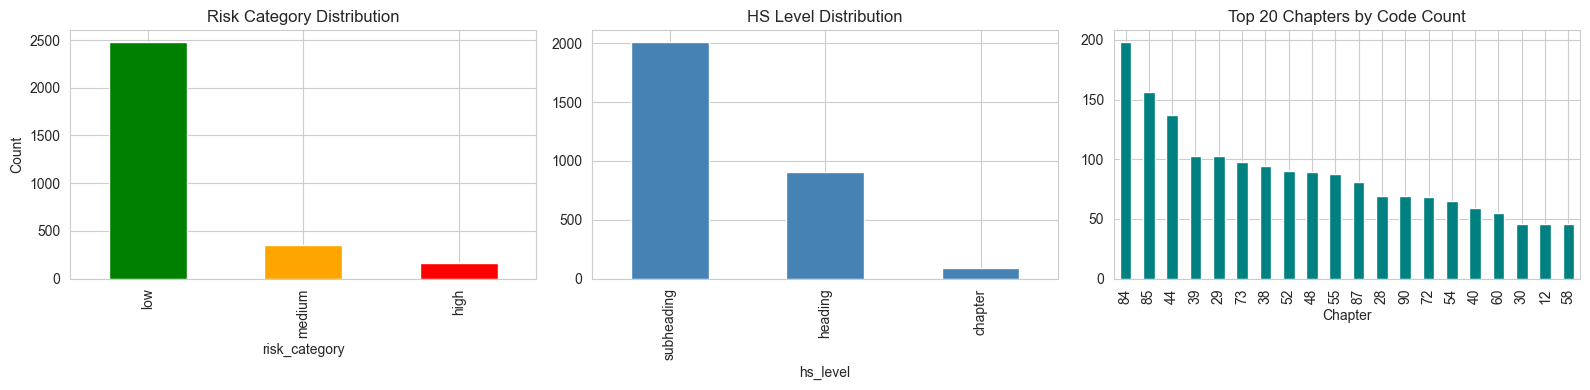

In [162]:
# ============================================================
# 4.2 Visualize HS code distribution by risk and level
# ============================================================
if hs_ontology is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # Risk distribution
    hs_ontology["risk_category"].value_counts().plot.bar(
        ax=axes[0], color=["green", "orange", "red"])
    axes[0].set_title("Risk Category Distribution")
    axes[0].set_ylabel("Count")
    
    # Level distribution
    hs_ontology["hs_level"].value_counts().plot.bar(
        ax=axes[1], color="steelblue")
    axes[1].set_title("HS Level Distribution")
    
    # Codes per chapter (top 20)
    hs_ontology["chapter"].value_counts().head(20).plot.bar(
        ax=axes[2], color="teal")
    axes[2].set_title("Top 20 Chapters by Code Count")
    axes[2].set_xlabel("Chapter")
    
    plt.tight_layout()
    plt.show()
else:
    print("No ontology to visualize.")

---
## 5. Synthetic Data Generation (Algorithm 1)

Generates **1 million** synthetic customs declarations (paper: Section III-B) with:
- **10% fraud prevalence** (realistic class imbalance)
- **4 fraud mechanisms:** (1) category shifting, (2) value underreporting, (3) description obfuscation, (4) origin misrepresentation
- Importer risk profiles (20% risky importers), duty rate structure
- Engineered features: value_per_kg, duty_gap, duty_ratio, fraud-rate aggregates

*Source: `clean_dataset_gen.ipynb`, `generate_the_data.py`, `customs_fraud_detection_system.py`*

In [163]:
# ============================================================
# 5.1 Generation constants
# ============================================================
NUM_TRANSACTIONS     = 1_000_000
BASE_FRAUD_RATE      = 0.10
N_IMPORTERS          = 500
RISKY_IMPORTER_SHARE = 0.20

ORIGIN_COUNTRIES = [
    "China", "Germany", "France", "Spain", "Turkey",
    "Morocco", "USA", "Brazil", "India", "Vietnam"
]

print(f"Target: {NUM_TRANSACTIONS:,} transactions, {BASE_FRAUD_RATE:.0%} fraud rate")

Target: 1,000,000 transactions, 10% fraud rate


In [164]:
# ============================================================
# 5.2 Data generation engine (Algorithm 1 from paper)
# ============================================================
def generate_synthetic_dataset(num_tx, ontology_df=None):
    np.random.seed(RANDOM_SEED)
    random.seed(RANDOM_SEED)
    
    # Use ontology for HS code sampling if available
    use_ontology = False
    if ontology_df is not None and len(ontology_df) > 0:
        hs = ontology_df[ontology_df["hs_level"].isin(["chapter", "heading"])].reset_index(drop=True)
        if "risk_category" not in hs.columns:
            hs["risk_category"] = np.random.choice(["low", "medium", "high"], len(hs), p=[.5,.3,.2])
        duty_map = {}
        for _, r in hs.iterrows():
            c = str(r["hs_code"])
            risk = r["risk_category"]
            duty_map[c] = np.random.uniform(
                *{"low": (0.01, 0.05), "medium": (0.05, 0.12), "high": (0.12, 0.25)}[risk])
        hs["duty_rate"] = hs["hs_code"].astype(str).map(duty_map)
        use_ontology = True
    
    importer_ids = [f"IMP_{i:04d}" for i in range(N_IMPORTERS)]
    risky = set(np.random.choice(importer_ids, int(RISKY_IMPORTER_SHARE * N_IMPORTERS), replace=False))
    
    def sample_hs(fraud=False, true_row=None):
        if use_ontology:
            if not fraud:
                probs = (1 / (hs["duty_rate"] + 1e-3)).values; probs /= probs.sum()
                return hs.iloc[np.random.choice(len(hs), p=probs)]
            else:
                td = true_row["duty_rate"]
                mask = hs["duty_rate"] < (td * 0.7) if np.random.rand() < 0.4 else \
                       (hs["duty_rate"] >= td * 0.7) & (hs["duty_rate"] <= td * 1.1)
                cands = hs[mask] if mask.any() else hs
                return cands.iloc[np.random.choice(len(cands))]
        else:
            return pd.Series({"hs_code": "0000", "designation": "product",
                              "chapter": "00", "hs_level": "heading",
                              "duty_rate": np.random.uniform(0.05, 0.20)})
    
    records = []
    for i in range(num_tx):
        imp = random.choice(importer_ids)
        is_risky = 1 if imp in risky else 0
        p_f = 0.22 if is_risky else 0.07
        is_fraud = int(np.random.rand() < p_f * BASE_FRAUD_RATE / 0.145)
        
        true_row = sample_hs()
        decl_row = sample_hs(True, true_row) if is_fraud else true_row
        
        ch = str(true_row.get("chapter", "00"))[:2]
        base_vpk = {"01": 3., "02": 3., "71": 500., "84": 50., "85": 50.}.get(ch, 10.)
        weight = np.random.gamma(2.0, 5.0) + 0.5
        vpk = np.random.lognormal(np.log(base_vpk), 0.35 if not is_fraud else 0.45)
        value = weight * vpk
        if is_fraud and np.random.rand() < 0.3:
            value *= np.random.uniform(0.4, 0.8)
        
        td_rate = true_row.get("duty_rate", 0.10)
        dd_rate = decl_row.get("duty_rate", 0.10) if is_fraud else td_rate
        adj = ["premium", "industrial", "bulk", "refined", "raw"]
        
        records.append({
            "transaction_id": i + 1,
            "product_name": f"{np.random.choice(adj)} {true_row.get('designation', 'product')}",
            "true_hs_code": str(true_row["hs_code"]),
            "declared_hs_code": str(decl_row["hs_code"]),
            "hs_level": decl_row.get("hs_level", "heading"),
            "weight_kg": round(weight, 2),
            "declared_value_usd": round(value, 2),
            "origin_country": random.choice(ORIGIN_COUNTRIES),
            "importer_id": imp,
            "importer_risk_flag": is_risky,
            "duty_true": round(value * td_rate, 2),
            "duty_declared": round(value * dd_rate, 2),
            "fraud_label": is_fraud,
        })
        if (i + 1) % 200_000 == 0:
            print(f"  {i+1:,} / {num_tx:,}...")
    
    df = pd.DataFrame(records)
    df["value_per_kg"] = df["declared_value_usd"] / (df["weight_kg"] + 1e-6)
    df["duty_gap"]     = df["duty_true"] - df["duty_declared"]
    df["duty_ratio"]   = df["duty_declared"] / (df["duty_true"] + 1e-6)
    df["chapter"]      = df["true_hs_code"].astype(str).str[:2]
    df["heading"]      = df["true_hs_code"].astype(str).str[:4]
    
    for col, grp in [("chapter_prev_fraud_rate", "chapter"),
                      ("heading_prev_fraud_rate", "heading")]:
        df[col] = df.groupby(grp)["fraud_label"].transform("mean")
    
    imp_agg = df.groupby("importer_id")["fraud_label"].agg(
        importer_total_declarations="count", importer_prev_fraud_rate="mean"
    ).reset_index()
    df = df.merge(imp_agg, on="importer_id", how="left")
    
    noise = np.random.rand(len(df)) < 0.03
    df.loc[noise, "fraud_label"] = 1 - df.loc[noise, "fraud_label"]
    
    print(f"\nGenerated {len(df):,} records, fraud rate: {df['fraud_label'].mean():.3f}")
    return df

print("Data generation engine defined.")

Data generation engine defined.


In [165]:
# ============================================================
# 5.3 Load existing dataset or generate new one
# ============================================================
if os.path.exists(TRANSACTIONS_CSV):
    print(f"Loading existing dataset: {TRANSACTIONS_CSV}")
    df = pd.read_csv(TRANSACTIONS_CSV)
    print(f"Loaded: {len(df):,} rows, {df.shape[1]} columns")
    print(f"Fraud rate: {df['fraud_label'].mean():.4f}")
else:
    print("Dataset not found. Generating...")
    df = generate_synthetic_dataset(NUM_TRANSACTIONS, hs_ontology)
    df.to_csv(TRANSACTIONS_CSV, index=False)
    print(f"Saved to {TRANSACTIONS_CSV}")

print(f"\nShape: {df.shape}")
display(df.head())

Loading existing dataset: C:\Users\Administrator\Desktop\fraud_detection\data\customs_transactions.csv
Loaded: 1,000,000 rows, 22 columns
Fraud rate: 0.0942

Shape: (1000000, 22)


,transaction_id,product_name,true_hs_code,declared_hs_code,hs_level,weight_kg,declared_value_usd,origin_country,importer_id,importer_risk_flag,...,fraud_label,value_per_kg,duty_gap,duty_ratio,chapter,heading,chapter_prev_fraud_rate,heading_prev_fraud_rate,importer_total_declarations,importer_prev_fraud_rate
0,1,refined Autres fibres textiles végétales; fils de papier et tissus de fils de papier > Fils de lin,5306,5306,heading,11.562369,165.887507,Germany,IMP_0327,0,...,0,14.347189,0.0,1.000000,53,5306,0.070798,0.069372,2024,0.052866
1,2,"refined Chaussures, guêtres et articles analogues; parties de ces objets > Autres chaussures",6405,6405,heading,6.459887,66.354563,Turkey,IMP_0012,0,...,0,10.271783,0.0,1.000000,64,6405,0.066289,0.063806,1892,0.057611
2,3,raw Instruments de musique; parties et accessoires de ces instruments > Autres instruments de musique à cordes (guit...,9202,9202,heading,2.112293,17.285885,Spain,IMP_0125,0,...,0,8.183465,0.0,0.999995,92,9202,0.066515,0.066537,2010,0.046766
3,4,"industrial Ouvrages en fonte, fer ou acier > Chaînes, chaînettes et leurs parties, en fonte, fer ou acier£- Chaînes ...",7315,7315,heading,5.412443,62.166536,Germany,IMP_0071,0,...,0,11.485853,0.0,1.000000,73,7315,0.069192,0.087500,1999,0.038519
4,5,"refined Sel; soufre; terres et pierres; plâtres, chaux et ciments > Carbonate de magnésium naturel (magnésite); magn...",2519,2519,heading,8.669468,130.692565,India,IMP_0346,0,...,0,15.075036,0.0,1.000000,25,2519,0.068418,0.063657,2039,0.046101


---
## 6. Dataset Exploratory Data Analysis

In [166]:
# ============================================================
# 6.1 Basic statistics
# ============================================================
print("Dataset Summary")
print("=" * 50)
print(f"Total records:     {len(df):,}")
print(f"Fraud cases:       {df['fraud_label'].sum():,.0f} ({df['fraud_label'].mean():.2%})")
print(f"Legitimate cases:  {(1 - df['fraud_label']).sum():,.0f}")
print(f"Unique importers:  {df['importer_id'].nunique()}")
print(f"Unique HS codes:   {df['declared_hs_code'].nunique()}")
print(f"Countries:         {df['origin_country'].nunique()}")
print(f"\nNumerical summary:")
display(df[["weight_kg", "declared_value_usd", "value_per_kg",
            "duty_true", "duty_declared", "duty_gap"]].describe().round(2))

Dataset Summary
Total records:     1,000,000
Fraud cases:       94,232 (9.42%)
Legitimate cases:  905,768
Unique importers:  500
Unique HS codes:   990
Countries:         10

Numerical summary:


,weight_kg,declared_value_usd,value_per_kg,duty_true,duty_declared,duty_gap
count,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00
mean,10.50,297.85,28.56,7.31,7.24,0.07
std,7.06,1070.61,84.34,23.82,23.72,3.40
min,0.51,1.36,1.24,0.03,0.02,-900.03
25%,5.31,56.14,8.26,1.19,1.18,0.00
50%,8.90,104.14,10.88,2.48,2.45,0.00
75%,13.96,199.16,15.62,5.59,5.52,0.00
max,80.23,101249.19,2255.60,2291.09,2291.09,731.17


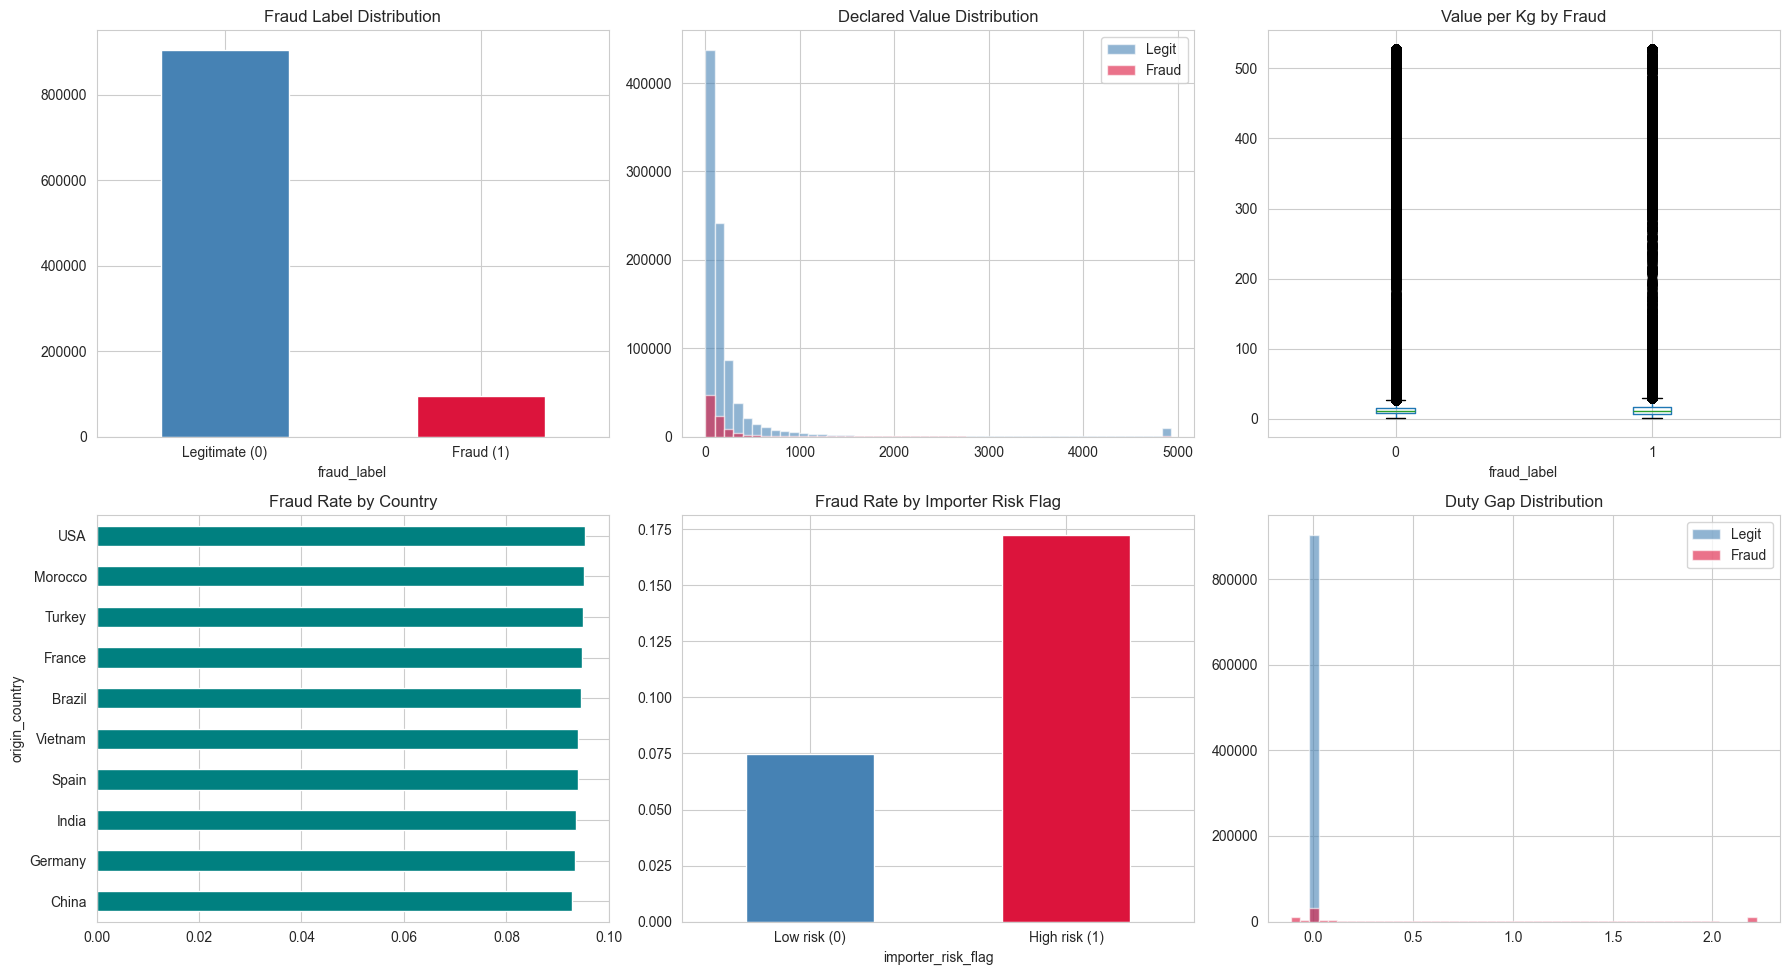

In [167]:
# ============================================================
# 6.2 Fraud distribution visualizations
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (a) Fraud label balance
df["fraud_label"].value_counts().plot.bar(ax=axes[0,0], color=["steelblue", "crimson"])
axes[0,0].set_title("Fraud Label Distribution")
axes[0,0].set_xticklabels(["Legitimate (0)", "Fraud (1)"], rotation=0)

# (b) Declared value by fraud
clip_val = df["declared_value_usd"].clip(upper=df["declared_value_usd"].quantile(0.99))
for label, color in [(0, "steelblue"), (1, "crimson")]:
    clip_val[df["fraud_label"] == label].hist(bins=50, ax=axes[0,1], alpha=0.6,
        color=color, label=f"{'Fraud' if label else 'Legit'}")
axes[0,1].set_title("Declared Value Distribution")
axes[0,1].legend()

# (c) Value per kg boxplot
vpk = df["value_per_kg"].clip(upper=df["value_per_kg"].quantile(0.99))
df.assign(vpk=vpk).boxplot(column="vpk", by="fraud_label", ax=axes[0,2])
axes[0,2].set_title("Value per Kg by Fraud")
plt.suptitle("")

# (d) Fraud rate by country
df.groupby("origin_country")["fraud_label"].mean().sort_values().plot.barh(
    ax=axes[1,0], color="teal")
axes[1,0].set_title("Fraud Rate by Country")

# (e) Fraud rate by importer risk flag
df.groupby("importer_risk_flag")["fraud_label"].mean().plot.bar(
    ax=axes[1,1], color=["steelblue", "crimson"])
axes[1,1].set_title("Fraud Rate by Importer Risk Flag")
axes[1,1].set_xticklabels(["Low risk (0)", "High risk (1)"], rotation=0)

# (f) Duty gap distribution
dg = df["duty_gap"].clip(lower=df["duty_gap"].quantile(0.01),
                          upper=df["duty_gap"].quantile(0.99))
for label, color in [(0, "steelblue"), (1, "crimson")]:
    dg[df["fraud_label"] == label].hist(bins=50, ax=axes[1,2], alpha=0.6,
        color=color, label=f"{'Fraud' if label else 'Legit'}")
axes[1,2].set_title("Duty Gap Distribution")
axes[1,2].legend()

plt.tight_layout()
plt.show()

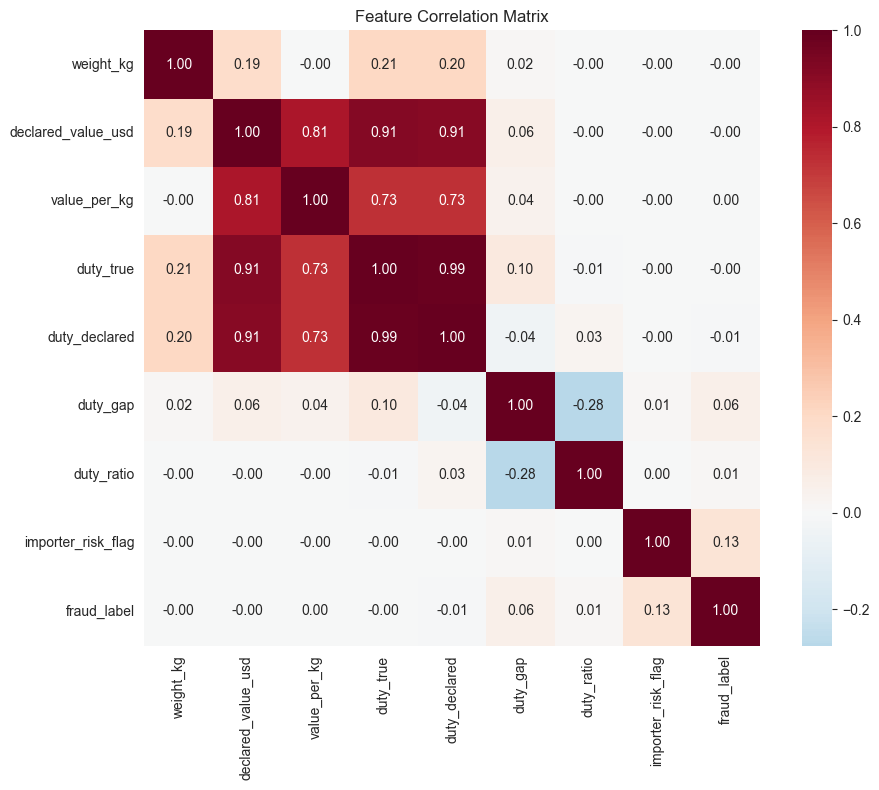

In [168]:
# ============================================================
# 6.3 Correlation heatmap of numerical features
# ============================================================
num_cols = ["weight_kg", "declared_value_usd", "value_per_kg",
            "duty_true", "duty_declared", "duty_gap", "duty_ratio",
            "importer_risk_flag", "fraud_label"]
num_cols = [c for c in num_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

---
## 7. Feature Engineering & 8. Train/Val/Test Split

In [169]:
# ============================================================
# 7.1 Define feature groups (Paper Section III-C)
# ============================================================
numeric_features = [
    "weight_kg", "declared_value_usd", "duty_true", "duty_declared",
    "duty_gap", "duty_ratio", "value_per_kg",
    "chapter_prev_fraud_rate", "heading_prev_fraud_rate",
    "importer_prev_fraud_rate", "importer_total_declarations",
]
categorical_features = [
    "origin_country", "importer_id", "hs_level",
    "importer_risk_flag", "chapter", "heading",
]
text_feature = "product_name"

# Verify all columns exist
numeric_features     = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]
tabular_cols = numeric_features + categorical_features

print(f"Numeric features     ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Text feature: {text_feature}")

Numeric features     (11): ['weight_kg', 'declared_value_usd', 'duty_true', 'duty_declared', 'duty_gap', 'duty_ratio', 'value_per_kg', 'chapter_prev_fraud_rate', 'heading_prev_fraud_rate', 'importer_prev_fraud_rate', 'importer_total_declarations']
Categorical features (6): ['origin_country', 'importer_id', 'hs_level', 'importer_risk_flag', 'chapter', 'heading']
Text feature: product_name


In [170]:
# ============================================================
# 8.1 Stratified train / validation / test split
# ============================================================
y = df["fraud_label"].astype(int)
X = df.drop(columns=["fraud_label"])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.75, stratify=y_temp, random_state=RANDOM_SEED)

print(f"Train: {X_train.shape[0]:>9,}  fraud rate: {y_train.mean():.4f}")
print(f"Val:   {X_val.shape[0]:>9,}  fraud rate: {y_val.mean():.4f}")
print(f"Test:  {X_test.shape[0]:>9,}  fraud rate: {y_test.mean():.4f}")

Train:   800,000  fraud rate: 0.0942
Val:      50,000  fraud rate: 0.0942
Test:    150,000  fraud rate: 0.0942


In [171]:
# ============================================================
# 8.2 Build or load preprocessing pipelines
# ============================================================
USE_PRETRAINED = "pipeline" in pretrained_models and "tfidf" in pretrained_models

if USE_PRETRAINED:
    print("Using pre-trained pipeline and vectorizer from saved models...")
    tabular_pipeline = pretrained_models["pipeline"]
    text_vectorizer  = pretrained_models["tfidf"]
    
    X_train_tab  = tabular_pipeline.transform(X_train)
    X_val_tab    = tabular_pipeline.transform(X_val)
    X_test_tab   = tabular_pipeline.transform(X_test)
    
    X_train_text = text_vectorizer.transform(X_train[text_feature])
    X_val_text   = text_vectorizer.transform(X_val[text_feature])
    X_test_text  = text_vectorizer.transform(X_test[text_feature])
else:
    print("Building new preprocessing pipelines...")
    tabular_pre = ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_features),
    ])
    tabular_pipeline = Pipeline([
        ("select", ColumnSelector(tabular_cols)),
        ("pre", tabular_pre),
    ])
    # max_features=8000 matches the saved vectorizer configuration
    text_vectorizer = TfidfVectorizer(
        max_features=8000, ngram_range=(1, 2), min_df=5, stop_words="english")
    
    X_train_tab  = tabular_pipeline.fit_transform(X_train)
    X_val_tab    = tabular_pipeline.transform(X_val)
    X_test_tab   = tabular_pipeline.transform(X_test)
    
    X_train_text = text_vectorizer.fit_transform(X_train[text_feature])
    X_val_text   = text_vectorizer.transform(X_val[text_feature])
    X_test_text  = text_vectorizer.transform(X_test[text_feature])

X_train_full = hstack([X_train_tab, X_train_text])
X_val_full   = hstack([X_val_tab,   X_val_text])
X_test_full  = hstack([X_test_tab,  X_test_text])

print(f"Tabular: {X_train_tab.shape[1]} features")
print(f"Text:    {X_train_text.shape[1]} features (max_features={text_vectorizer.max_features})")
print(f"Full:    {X_train_full.shape[1]} features")

Using pre-trained pipeline and vectorizer from saved models...
Tabular: 1602 features
Text:    8000 features (max_features=8000)
Full:    9602 features


---
## 9. XGBoost Classifier Training & 10. Evaluation

In [172]:
# ============================================================
# 9.1 Load pre-trained XGBoost or train with saved hyperparameters
# ============================================================
if "xgb" in pretrained_models:
    print("Using pre-trained XGBoost model from saved artifacts...")
    xgb_model = pretrained_models["xgb"]
    print(f"  n_estimators={xgb_model.n_estimators}, max_depth={xgb_model.max_depth}, "
          f"learning_rate={xgb_model.learning_rate}")
    xgb_time = 0.0
else:
    # Train with the EXACT hyperparameters from the saved model
    # (determined by Bayesian optimization: n_estimators=600, max_depth=6)
    xgb_model = xgb.XGBClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, gamma=0.2,
        objective="binary:logistic", eval_metric="aucpr",
        n_jobs=-1, tree_method="hist", random_state=RANDOM_SEED,
    )
    print("Training XGBoost (n_estimators=600, max_depth=6)...")
    t0 = time.time()
    xgb_model.fit(X_train_full, y_train, eval_set=[(X_val_full, y_val)], verbose=False)
    xgb_time = time.time() - t0
    print(f"Done in {xgb_time:.1f}s")

Using pre-trained XGBoost model from saved artifacts...
  n_estimators=600, max_depth=6, learning_rate=0.05


In [173]:
# ============================================================
# 10.1 Threshold tuning on validation set
# ============================================================
y_val_proba_xgb = xgb_model.predict_proba(X_val_full)[:, 1]
prec_v, rec_v, thr_v = precision_recall_curve(y_val, y_val_proba_xgb)
prec_v, rec_v, thr_v = prec_v[:-1], rec_v[:-1], thr_v
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)
best_thr_xgb = thr_v[f1_v.argmax()]

print(f"Validation AUC-PR: {average_precision_score(y_val, y_val_proba_xgb):.4f}")
print(f"Best F1 threshold: {best_thr_xgb:.4f}")
print(f"At threshold -> Prec: {prec_v[f1_v.argmax()]:.3f}, Rec: {rec_v[f1_v.argmax()]:.3f}, F1: {f1_v.max():.3f}")

Validation AUC-PR: 0.7328
Best F1 threshold: 0.8707
At threshold -> Prec: 0.971, Rec: 0.690, F1: 0.807


In [174]:
# ============================================================
# 10.2 Test evaluation
# ============================================================
y_test_proba_xgb = xgb_model.predict_proba(X_test_full)[:, 1]
y_test_pred_xgb  = (y_test_proba_xgb >= best_thr_xgb).astype(int)

xgb_acc  = accuracy_score(y_test, y_test_pred_xgb)
xgb_prec = precision_score(y_test, y_test_pred_xgb)
xgb_rec  = recall_score(y_test, y_test_pred_xgb)
xgb_f1   = f1_score(y_test, y_test_pred_xgb)
xgb_ap   = average_precision_score(y_test, y_test_proba_xgb)

print("XGBoost (full) — Test Performance")
print("=" * 50)
print(f"Accuracy:  {xgb_acc:.3f}")
print(f"Precision: {xgb_prec:.3f}")
print(f"Recall:    {xgb_rec:.3f}")
print(f"F1-Score:  {xgb_f1:.3f}")
print(f"AUC-PR:    {xgb_ap:.3f}")
print()
print(classification_report(y_test, y_test_pred_xgb, digits=4, target_names=["Legitimate","Fraud"]))

XGBoost (full) — Test Performance
Accuracy:  0.969
Precision: 0.970
Recall:    0.695
F1-Score:  0.810
AUC-PR:    0.738

              precision    recall  f1-score   support

  Legitimate     0.9692    0.9977    0.9833    135866
       Fraud     0.9696    0.6951    0.8097     14134

    accuracy                         0.9692    150000
   macro avg     0.9694    0.8464    0.8965    150000
weighted avg     0.9692    0.9692    0.9669    150000



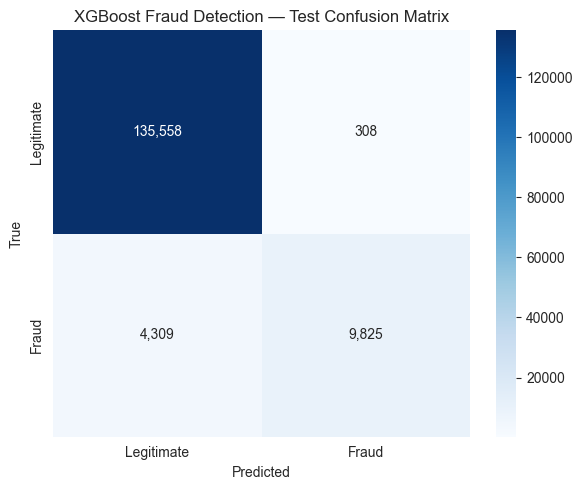

In [175]:
# ============================================================
# 10.3 XGBoost confusion matrix (Figure 3)
# ============================================================
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Legitimate","Fraud"], yticklabels=["Legitimate","Fraud"], ax=ax)
ax.set_title("XGBoost Fraud Detection — Test Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

In [176]:
# ============================================================
# 10.4 Save XGBoost model (only if newly trained)
# ============================================================
if "xgb" not in pretrained_models:
    joblib.dump(xgb_model, os.path.join(MODEL_DIR, "xgb_fraud_model_trained.joblib"))
    joblib.dump(tabular_pipeline, os.path.join(MODEL_DIR, "tabular_pipeline.joblib"))
    joblib.dump(text_vectorizer, os.path.join(MODEL_DIR, "text_vectorizer.joblib"))
    print(f"Models saved to {MODEL_DIR}")
else:
    print(f"Using pre-trained models from {MODEL_DIR} (no save needed).")

Using pre-trained models from C:\Users\Administrator\Desktop\fraud_detection\models (no save needed).


---
## 11. Random Forest Baseline & 12. Logistic Regression & 13. XGBoost Structured-Only

In [177]:
# ============================================================
# 11.1 Random Forest — load pre-trained or retrain
# ============================================================
if "rf" in pretrained_models:
    print("Using pre-trained Random Forest model...")
    rf_model = pretrained_models["rf"]
    print(f"  n_estimators={rf_model.n_estimators}, max_depth={rf_model.max_depth}")
else:
    rf_model = RandomForestClassifier(
        n_estimators=150, max_depth=12, min_samples_split=4, min_samples_leaf=4,
        max_features="sqrt", class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED)
    print("Training Random Forest...")
    t0 = time.time()
    rf_model.fit(X_train_full, y_train)
    print(f"Done in {time.time()-t0:.1f}s")

y_vp_rf = rf_model.predict_proba(X_val_full)[:, 1]
p_rf, r_rf, t_rf = precision_recall_curve(y_val, y_vp_rf)
p_rf, r_rf, t_rf = p_rf[:-1], r_rf[:-1], t_rf
f1_rf_v = 2 * p_rf * r_rf / (p_rf + r_rf + 1e-9)
best_thr_rf = t_rf[f1_rf_v.argmax()]

y_test_proba_rf = rf_model.predict_proba(X_test_full)[:, 1]
y_test_pred_rf  = (y_test_proba_rf >= best_thr_rf).astype(int)
rf_f1 = f1_score(y_test, y_test_pred_rf)
print(f"RF Test F1: {rf_f1:.3f}")
print(classification_report(y_test, y_test_pred_rf, digits=4, target_names=["Legitimate","Fraud"]))

Using pre-trained Random Forest model...
  n_estimators=150, max_depth=12
RF Test F1: 0.685
              precision    recall  f1-score   support

  Legitimate     0.9534    0.9979    0.9752    135866
       Fraud     0.9638    0.5311    0.6848     14134

    accuracy                         0.9539    150000
   macro avg     0.9586    0.7645    0.8300    150000
weighted avg     0.9544    0.9539    0.9478    150000



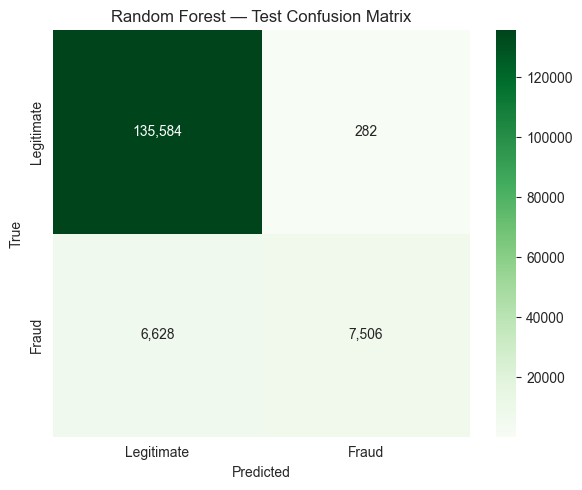

Using pre-trained RF model from C:\Users\Administrator\Desktop\fraud_detection\models


In [178]:
# ============================================================
# 11.2 RF confusion matrix (Figure 2)
# ============================================================
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt=",d", cmap="Greens",
            xticklabels=["Legitimate","Fraud"], yticklabels=["Legitimate","Fraud"], ax=ax)
ax.set_title("Random Forest \u2014 Test Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

if "rf" not in pretrained_models:
    joblib.dump(rf_model, os.path.join(MODEL_DIR, "rf_fraud_model.joblib"))
    print(f"RF model saved to {MODEL_DIR}")
else:
    print(f"Using pre-trained RF model from {MODEL_DIR}")

In [179]:
# ============================================================
# 12.1 Logistic Regression baseline
# ============================================================
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)
print("Training Logistic Regression...")
lr_model.fit(X_train_full, y_train)
y_test_pred_lr = lr_model.predict(X_test_full)
y_test_proba_lr = lr_model.predict_proba(X_test_full)[:, 1]
lr_f1 = f1_score(y_test, y_test_pred_lr)
print(f"LR Test F1: {lr_f1:.3f}")

Training Logistic Regression...
LR Test F1: 0.238


In [180]:
# ============================================================
# 13.1 XGBoost structured-only (no text features) — for ablation
# ============================================================
xgb_struct = xgb.XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=9,
    n_jobs=-1, tree_method="hist", random_state=RANDOM_SEED)
print("Training XGBoost (structured-only, no text)...")
xgb_struct.fit(X_train_tab, y_train, eval_set=[(X_val_tab, y_val)], verbose=False)
y_test_pred_struct = xgb_struct.predict(X_test_tab)
struct_f1 = f1_score(y_test, y_test_pred_struct)
print(f"XGBoost (structured) Test F1: {struct_f1:.3f}")

Training XGBoost (structured-only, no text)...
XGBoost (structured) Test F1: 0.810


---
## 14. Model Comparison — Table I & 15. PR Curves

In [181]:
# ============================================================
# 14.1 Table I: Classifier Performance on Synthetic Test Set
# ============================================================
def model_metrics(name, y_true, y_pred):
    return {"Model": name, "Acc.": round(accuracy_score(y_true, y_pred), 3),
            "Prec.": round(precision_score(y_true, y_pred), 3),
            "Recall": round(recall_score(y_true, y_pred), 3),
            "F1": round(f1_score(y_true, y_pred), 3)}

table1 = pd.DataFrame([
    model_metrics("Logistic Regression", y_test, y_test_pred_lr),
    model_metrics("Random Forest",       y_test, y_test_pred_rf),
    model_metrics("XGBoost (structured)", y_test, y_test_pred_struct),
    model_metrics("XGBoost (full)",      y_test, y_test_pred_xgb),
])
print("=" * 65)
print("TABLE I: Classifier Performance on Synthetic Test Set (Fraud Class)")
print("=" * 65)
display(table1)

TABLE I: Classifier Performance on Synthetic Test Set (Fraud Class)


,Model,Acc.,Prec.,Recall,F1
0,Logistic Regression,0.746,0.166,0.422,0.238
1,Random Forest,0.954,0.964,0.531,0.685
2,XGBoost (structured),0.969,0.969,0.695,0.810
3,XGBoost (full),0.969,0.970,0.695,0.810


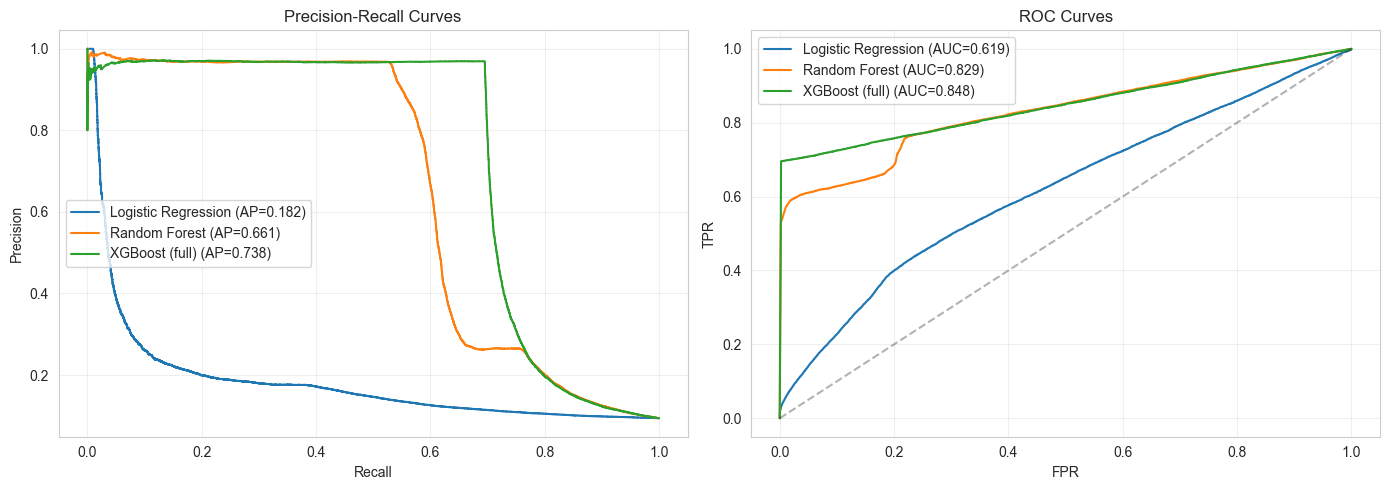

In [182]:
# ============================================================
# 15.1 Precision-Recall curves comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in [("Logistic Regression", y_test_proba_lr),
                     ("Random Forest", y_test_proba_rf),
                     ("XGBoost (full)", y_test_proba_xgb)]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[0].plot(r, p, label=f"{name} (AP={ap:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curves"); axes[0].legend(); axes[0].grid(True, alpha=.3)

# ROC curves
for name, proba in [("Logistic Regression", y_test_proba_lr),
                     ("Random Forest", y_test_proba_rf),
                     ("XGBoost (full)", y_test_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[1].plot([0,1],[0,1],'k--',alpha=.3)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curves"); axes[1].legend(); axes[1].grid(True, alpha=.3)

plt.tight_layout(); plt.show()

### 15.2 Threshold Sensitivity Analysis
F1, Precision, and Recall as a function of the decision threshold — critical for selecting the operating point in production.

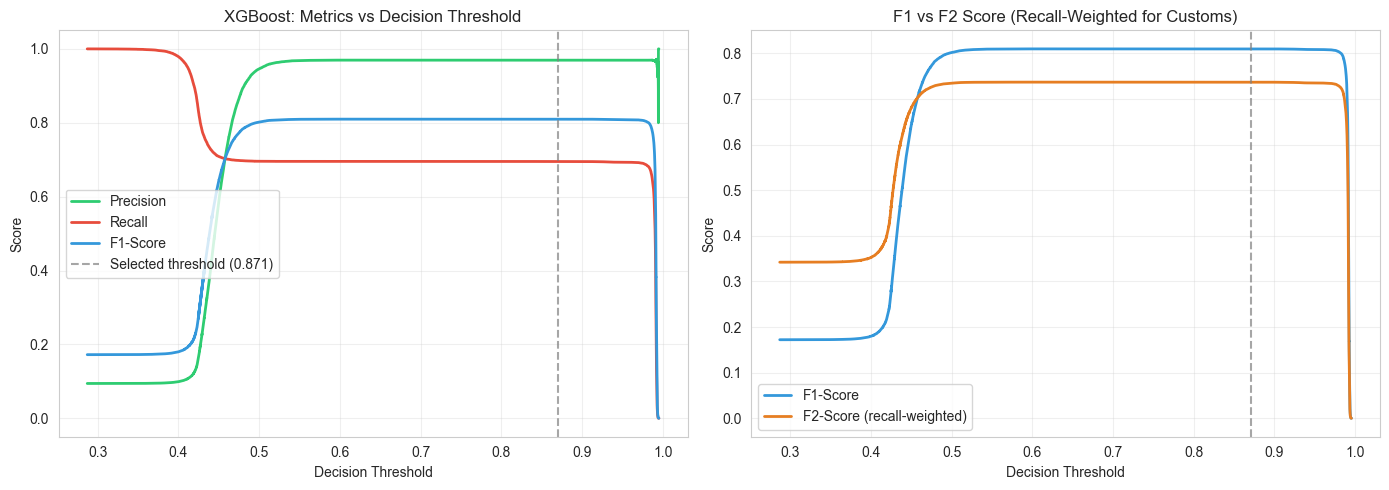

In [183]:
# ============================================================
# 15.2 Threshold sensitivity analysis (XGBoost)
# ============================================================
prec_t, rec_t, thr_t = precision_recall_curve(y_test, y_test_proba_xgb)
prec_t, rec_t, thr_t = prec_t[:-1], rec_t[:-1], thr_t
f1_t = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Metrics vs threshold
axes[0].plot(thr_t, prec_t, label="Precision", color="#2ecc71", linewidth=2)
axes[0].plot(thr_t, rec_t, label="Recall", color="#e74c3c", linewidth=2)
axes[0].plot(thr_t, f1_t, label="F1-Score", color="#3498db", linewidth=2)
axes[0].axvline(best_thr_xgb, color="gray", ls="--", alpha=0.7, label=f"Selected threshold ({best_thr_xgb:.3f})")
axes[0].set_xlabel("Decision Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("XGBoost: Metrics vs Decision Threshold")
axes[0].legend(loc="center left")
axes[0].grid(True, alpha=0.3)

# (b) F2 score vs threshold (recall-oriented for customs fraud)
f2_t = 5 * prec_t * rec_t / (4 * prec_t + rec_t + 1e-9)
axes[1].plot(thr_t, f1_t, label="F1-Score", color="#3498db", linewidth=2)
axes[1].plot(thr_t, f2_t, label="F2-Score (recall-weighted)", color="#e67e22", linewidth=2)
axes[1].axvline(best_thr_xgb, color="gray", ls="--", alpha=0.7)
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("F1 vs F2 Score (Recall-Weighted for Customs)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 15.3 Calibration Curve (Reliability Diagram)
Shows how well predicted fraud probabilities match actual fraud rates — essential for trustworthy risk scoring.

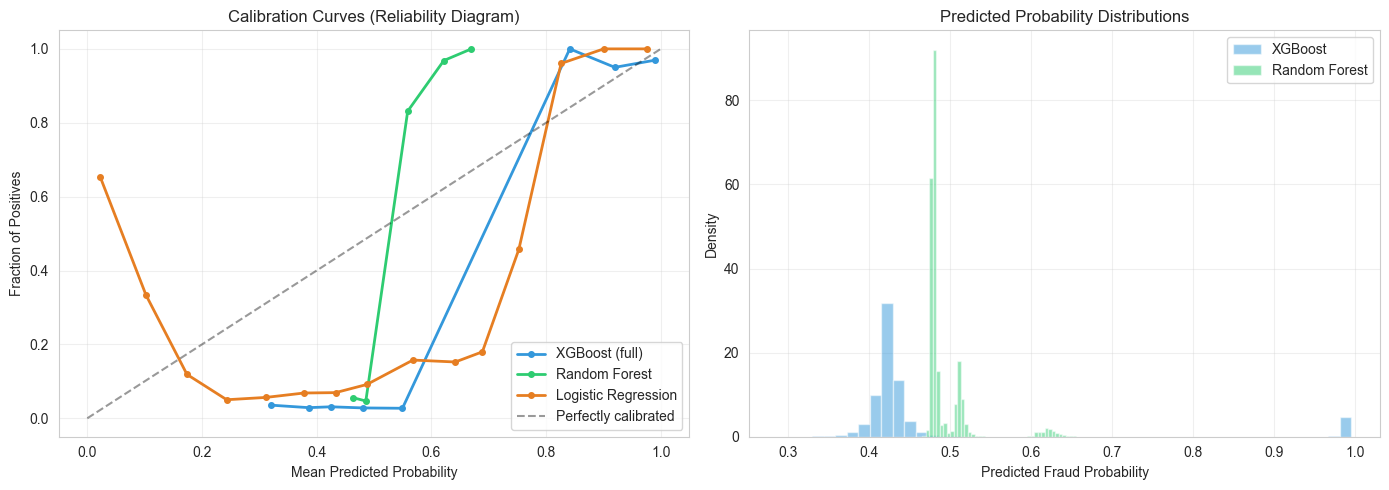

In [184]:
# ============================================================
# 15.3 Calibration curve
# ============================================================
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba, color in [
    ("XGBoost (full)", y_test_proba_xgb, "#3498db"),
    ("Random Forest", y_test_proba_rf, "#2ecc71"),
    ("Logistic Regression", y_test_proba_lr, "#e67e22"),
]:
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=15, strategy="uniform")
    axes[0].plot(prob_pred, prob_true, "o-", label=name, color=color, linewidth=2, markersize=4)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Positives")
axes[0].set_title("Calibration Curves (Reliability Diagram)")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Predicted probability distributions
for name, proba, color in [
    ("XGBoost", y_test_proba_xgb, "#3498db"),
    ("Random Forest", y_test_proba_rf, "#2ecc71"),
]:
    axes[1].hist(proba, bins=50, alpha=0.5, label=name, color=color, density=True)
axes[1].set_xlabel("Predicted Fraud Probability")
axes[1].set_ylabel("Density")
axes[1].set_title("Predicted Probability Distributions")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 15.4 Class-Conditional Feature Density Plots
Feature distributions conditioned on fraud vs legitimate — reveals which features best separate the classes.

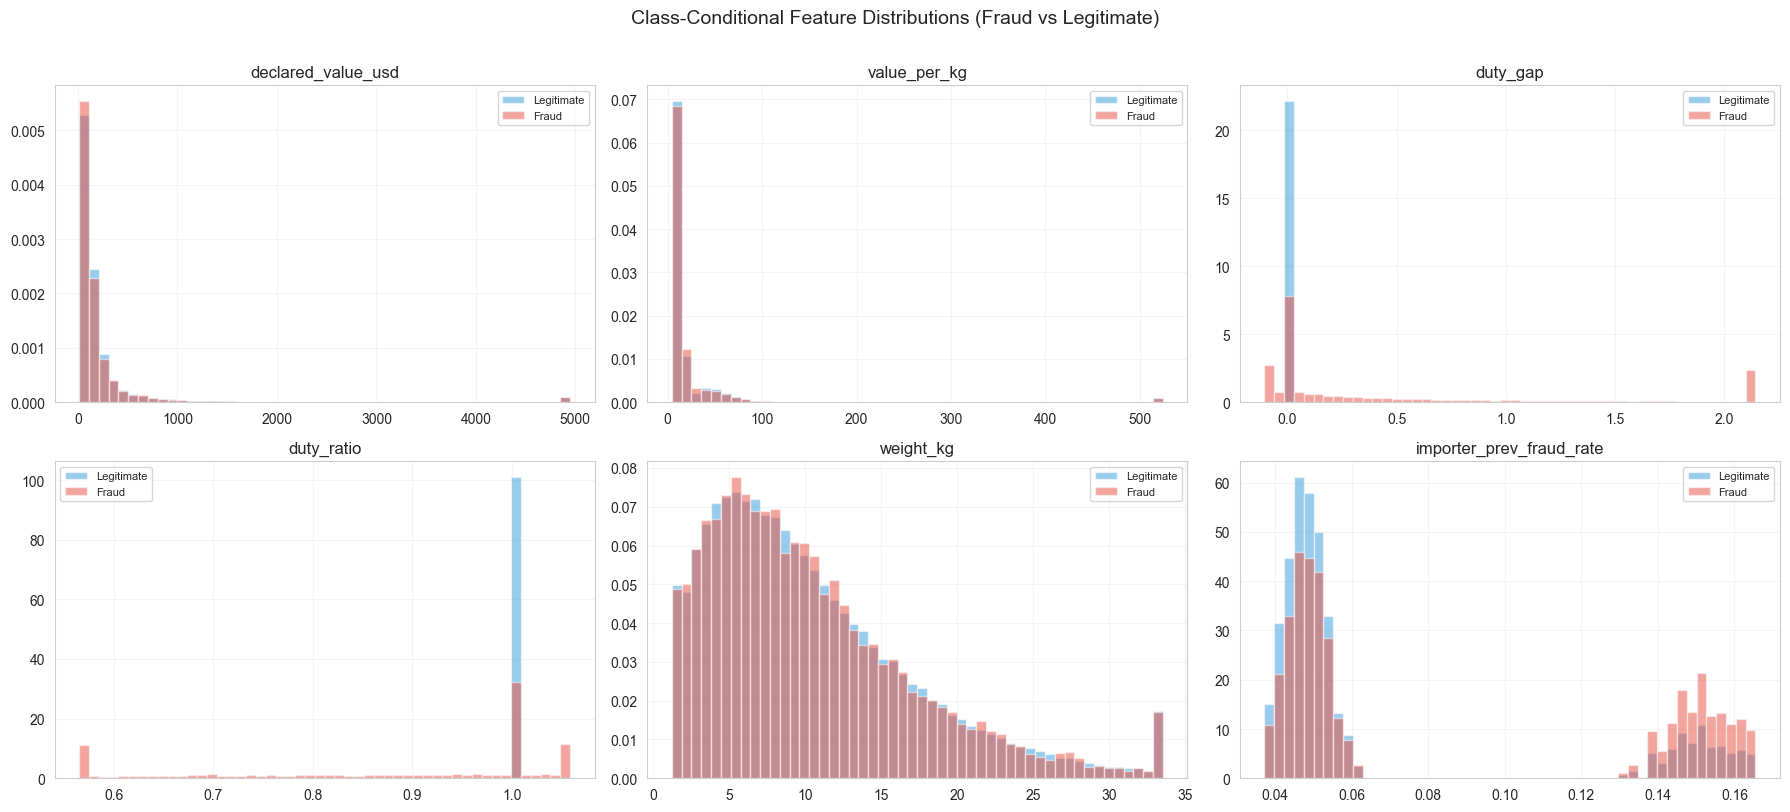

In [185]:
# ============================================================
# 15.4 Class-conditional density plots for key features
# ============================================================
key_features = ["declared_value_usd", "value_per_kg", "duty_gap", "duty_ratio",
                "weight_kg", "importer_prev_fraud_rate"]
key_features = [f for f in key_features if f in X_test.columns]

n_feat = len(key_features)
n_cols = 3
n_rows = (n_feat + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten() if n_feat > 1 else [axes]

for j, feat in enumerate(key_features):
    ax = axes[j]
    vals = X_test[feat]
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)

    fraud_vals = vals[y_test.values == 1].clip(lo, hi)
    legit_vals = vals[y_test.values == 0].clip(lo, hi)

    ax.hist(legit_vals, bins=50, alpha=0.5, density=True, color="#3498db", label="Legitimate")
    ax.hist(fraud_vals, bins=50, alpha=0.5, density=True, color="#e74c3c", label="Fraud")
    ax.set_title(feat)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

# Hide unused subplots
for j in range(n_feat, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Class-Conditional Feature Distributions (Fraud vs Legitimate)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 15.5 Confusion Matrices — All Models Side-by-Side

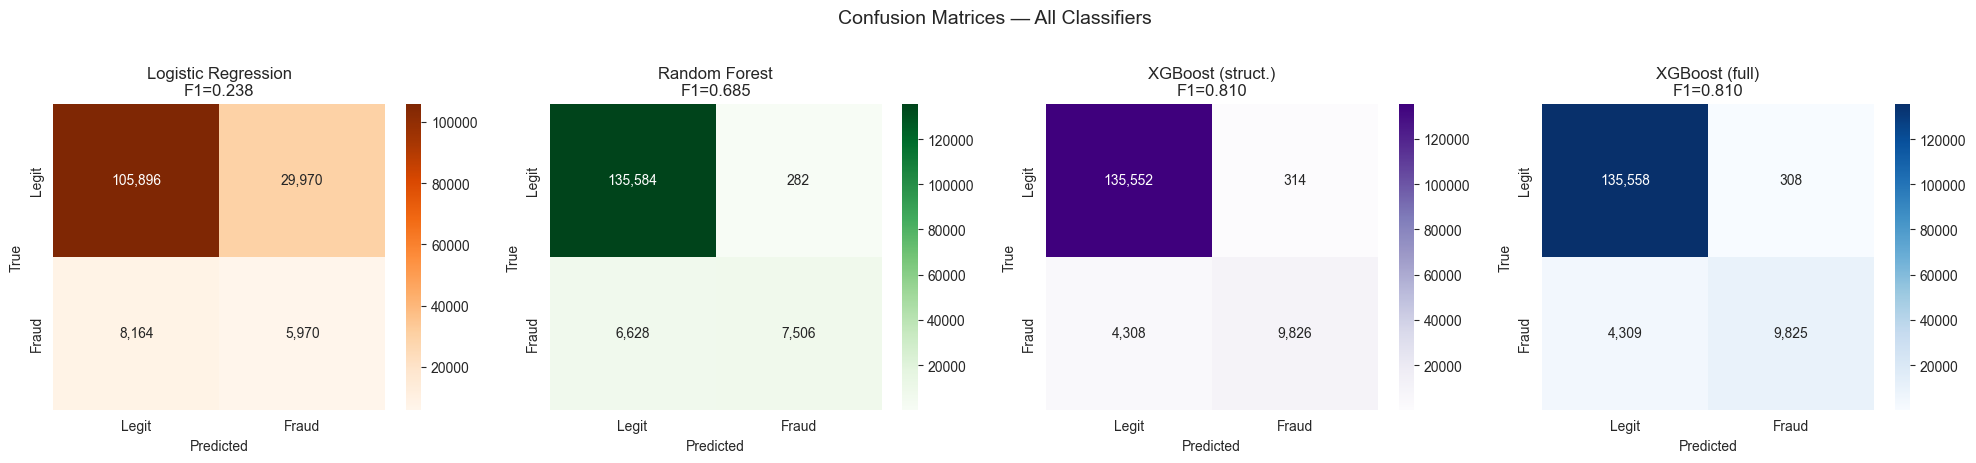

In [186]:
# ============================================================
# 15.5 Confusion matrices for all classifiers
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (name, preds, cmap) in zip(axes, [
    ("Logistic Regression", y_test_pred_lr, "Oranges"),
    ("Random Forest", y_test_pred_rf, "Greens"),
    ("XGBoost (struct.)", y_test_pred_struct, "Purples"),
    ("XGBoost (full)", y_test_pred_xgb, "Blues"),
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt=",d", cmap=cmap,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"], ax=ax)
    f1 = f1_score(y_test, preds)
    ax.set_title(f"{name}\nF1={f1:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices — All Classifiers", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 16. Ablation Studies — Table IV

In [187]:
# ============================================================
# 16.1 Ablation helper
# ============================================================
def train_ablation(num_feats, cat_feats, use_text=True):
    """Train an XGBoost with a subset of features and return test F1."""
    tp = ColumnTransformer(transformers=[
        ("num", StandardScaler(), num_feats),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_feats),
    ])
    pipe = Pipeline([("select", ColumnSelector(num_feats + cat_feats)), ("pre", tp)])
    Xtr = pipe.fit_transform(X_train)
    Xte = pipe.transform(X_test)
    if use_text:
        Xtr = hstack([Xtr, X_train_text])
        Xte = hstack([Xte, X_test_text])
    m = xgb.XGBClassifier(
        n_estimators=500, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=9,
        n_jobs=-1, tree_method="hist", random_state=RANDOM_SEED)
    m.fit(Xtr, y_train)
    return f1_score(y_test, m.predict(Xte))

print("Ablation helper defined.")

Ablation helper defined.


In [188]:
# ============================================================
# 16.2 Run ablation experiments
# ============================================================
f1_full = xgb_f1
f1_no_text = struct_f1  # already computed

# Remove target encoding
no_te = [f for f in numeric_features if f not in
         ["chapter_prev_fraud_rate", "heading_prev_fraud_rate", "importer_prev_fraud_rate"]]
print("Ablation: without target encoding...")
f1_no_te = train_ablation(no_te, categorical_features, True)
print(f"  F1 = {f1_no_te:.3f} (delta: {f1_no_te - f1_full:+.3f})")

# Remove value deviation
no_vd = [f for f in numeric_features if f != "value_per_kg"]
print("Ablation: without value_per_kg...")
f1_no_vd = train_ablation(no_vd, categorical_features, True)
print(f"  F1 = {f1_no_vd:.3f} (delta: {f1_no_vd - f1_full:+.3f})")

Ablation: without target encoding...
  F1 = 0.810 (delta: -0.000)
Ablation: without value_per_kg...
  F1 = 0.810 (delta: -0.000)


In [189]:
# ============================================================
# 16.3 TABLE IV: Ablation Summary
# ============================================================
ablation = pd.DataFrame([
    {"Configuration": "Full System",             "F1": round(f1_full,3),    "Delta": "—"},
    {"Configuration": "- Text features (TF-IDF)", "F1": round(f1_no_text,3), "Delta": f"{f1_no_text-f1_full:+.3f}"},
    {"Configuration": "- Target encoding",       "F1": round(f1_no_te,3),   "Delta": f"{f1_no_te-f1_full:+.3f}"},
    {"Configuration": "- Value deviation",       "F1": round(f1_no_vd,3),   "Delta": f"{f1_no_vd-f1_full:+.3f}"},
    {"Configuration": "XGB -> Random Forest",    "F1": round(rf_f1,3),      "Delta": f"{rf_f1-f1_full:+.3f}"},
])
print("=" * 55)
print("TABLE IV: Ablation Study Results (Synthetic Test Set)")
print("=" * 55)
display(ablation)

TABLE IV: Ablation Study Results (Synthetic Test Set)


,Configuration,F1,Delta
0,Full System,0.810,—
1,- Text features (TF-IDF),0.810,-0.000
2,- Target encoding,0.810,-0.000
3,- Value deviation,0.810,-0.000
4,XGB -> Random Forest,0.685,-0.125


### 15.6 Ablation Study — Visual Comparison

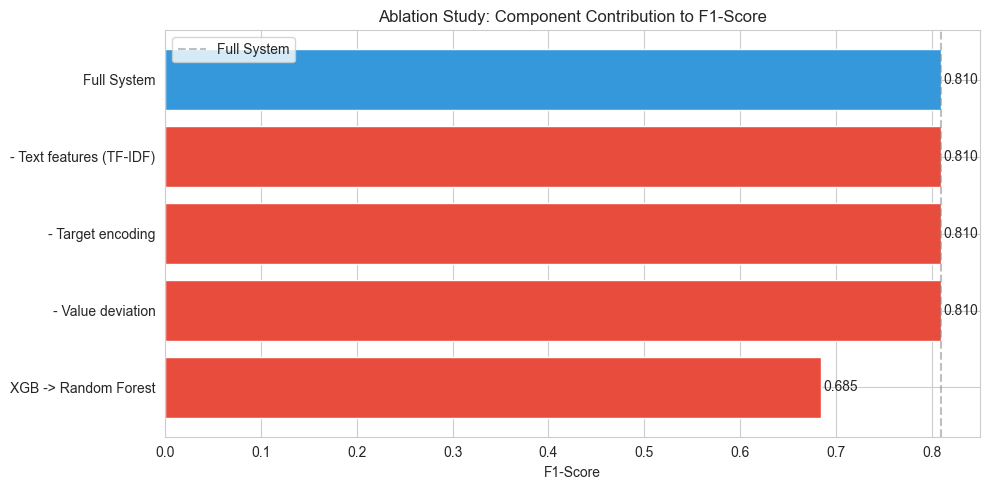

In [190]:
# ============================================================
# 15.6 Ablation study visualization (Table IV as bar chart)
# ============================================================
abl_data = ablation.copy()
abl_data["F1_val"] = abl_data["F1"].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71"] + ["#e74c3c"] * (len(abl_data) - 1)
colors[0] = "#3498db"  # Full system in blue
bars = ax.barh(abl_data["Configuration"][::-1], abl_data["F1_val"][::-1], color=colors[::-1])
ax.set_xlabel("F1-Score")
ax.set_title("Ablation Study: Component Contribution to F1-Score")
ax.axvline(abl_data["F1_val"].iloc[0], color="gray", ls="--", alpha=0.5, label="Full System")

for bar, val in zip(bars, abl_data["F1_val"][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

---
## 17. Feature Importance Analysis

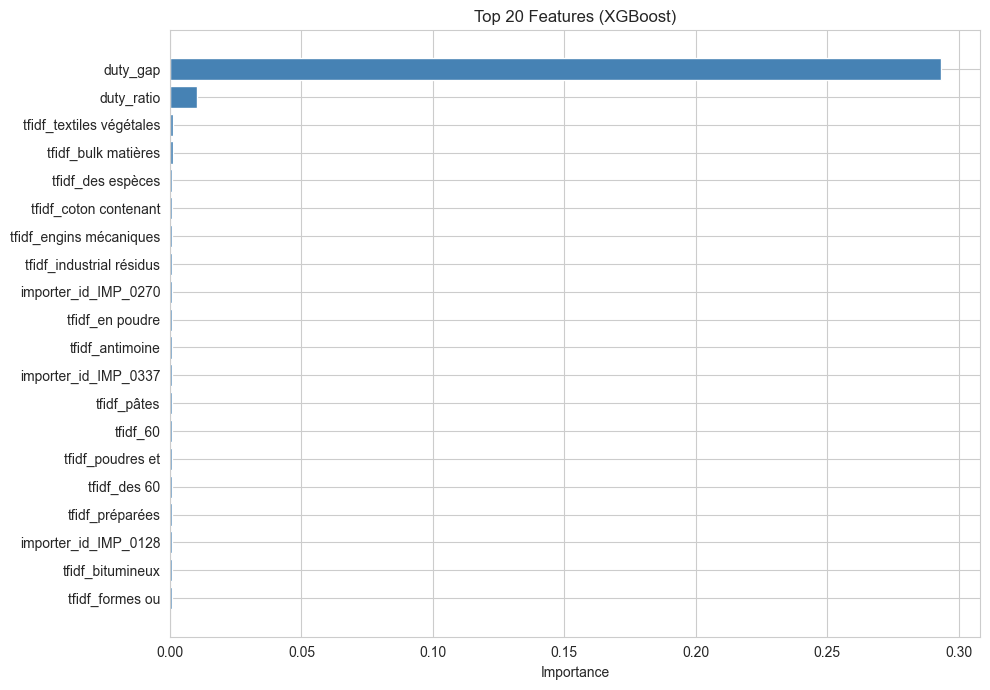

,Feature,Importance
0,duty_gap,0.293411
1,duty_ratio,0.010198
2,tfidf_textiles végétales,0.001169
3,tfidf_bulk matières,0.001126
4,tfidf_des espèces,0.000957
5,tfidf_coton contenant,0.000882
6,tfidf_engins mécaniques,0.000877
7,tfidf_industrial résidus,0.000850
8,importer_id_IMP_0270,0.000845
9,tfidf_en poudre,0.000844


In [191]:
# ============================================================
# 17.1 Top 20 features
# ============================================================
cat_names = []
for name, tr, cols in tabular_pipeline.named_steps['pre'].transformers_:
    if name == 'cat':
        try: cat_names.extend(tr.get_feature_names_out(cols))
        except: cat_names.extend([f"cat_{i}" for i in range(tr.transform(X_train[cols].head(1)).shape[1])])

tfidf_names = [f"tfidf_{w}" for w in text_vectorizer.get_feature_names_out()]
all_feat_names = numeric_features + list(cat_names) + tfidf_names

importances = xgb_model.feature_importances_
if len(all_feat_names) == len(importances):
    imp_df = pd.DataFrame({"Feature": all_feat_names, "Importance": importances})
    imp_df = imp_df.sort_values("Importance", ascending=False).head(20)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1], color="steelblue")
    ax.set_xlabel("Importance"); ax.set_title("Top 20 Features (XGBoost)")
    plt.tight_layout(); plt.show()
    display(imp_df.reset_index(drop=True))
else:
    print(f"Mismatch: {len(all_feat_names)} names vs {len(importances)} values")

---
## 18-20. RAG Pipeline — Agent 1: HS Code Prediction

In [192]:
# ============================================================
# 18.1 Use pre-loaded or build FAISS index over HS codes
# ============================================================
if RAG_AVAILABLE:
    if FAISS_PRELOADED:
        print(f"Using pre-loaded FAISS index: {hs_faiss_index.ntotal} vectors, dim={hs_faiss_index.d}")
        print(f"Encoder: {enc_name}")
        print(f"Metadata shape: {codes_meta.shape}")
    elif hs_ontology is not None:
        print("Building FAISS index from ontology...")
        hs_df = hs_ontology.dropna(subset=["hs_code", "designation"]).reset_index(drop=True)
        enc_name = "sentence-transformers/all-MiniLM-L6-v2"
        hs_encoder = SentenceTransformer(enc_name)
        texts = (hs_df["hs_code"].astype(str) + " - " + hs_df["designation"]).tolist()
        embeds = hs_encoder.encode(texts, batch_size=64, show_progress_bar=True).astype("float32")
        faiss.normalize_L2(embeds)
        hs_faiss_index = faiss.IndexFlatIP(embeds.shape[1])
        hs_faiss_index.add(embeds)
        codes_meta = hs_df[["hs_code", "designation"]].copy()
        faiss.write_index(hs_faiss_index, os.path.join(RAG_DIR, "hs_index.faiss"))
        joblib.dump(codes_meta, os.path.join(RAG_DIR, "hs_metadata.pkl"))
        joblib.dump(enc_name, os.path.join(RAG_DIR, "hs_encoder_name.pkl"))
        FAISS_PRELOADED = True
        print(f"Built and saved: {hs_faiss_index.ntotal} vectors")
    else:
        print("No ontology available to build FAISS index.")
else:
    print("RAG not available.")

Using pre-loaded FAISS index: 3000 vectors, dim=384
Encoder: sentence-transformers/all-MiniLM-L6-v2
Metadata shape: (3000, 2)


In [193]:
# ============================================================
# 19.1 RAG retrieval and LLM prompt functions
# ============================================================
def retrieve_hs_candidates(product_text, k=5):
    q = hs_encoder.encode([product_text]).astype("float32")
    faiss.normalize_L2(q)
    D, I = hs_faiss_index.search(q, k=k)
    result = codes_meta.iloc[I[0]].copy()
    result["score"] = D[0]
    return result

def build_classification_prompt(product_text, declared_code, candidates_df):
    lines = ["You are a customs HS classification expert.",
             "Decide whether the declared HS code is correct.", "",
             f"Product description: {product_text}", "",
             "Candidate HS codes from official nomenclature:"]
    for _, r in candidates_df.iterrows():
        lines.append(f"  - {r['hs_code']}: {r['designation']}")
    lines += ["", f"Declared HS code: {declared_code}",
              'Answer in JSON: {"selected_hs_code":"XXXX","is_declared_correct":true/false,"reason":"..."}']
    return "\n".join(lines)

if RAG_AVAILABLE:
    print("RAG functions defined.")
    # Demo retrieval
    demo = retrieve_hs_candidates("premium electronic smartphone", k=5)
    print(f"\nDemo retrieval for 'premium electronic smartphone':")
    display(demo)

RAG functions defined.



Demo retrieval for 'premium electronic smartphone':


,hs_code,designation,score
971,8517,"Machines, appareils et matériels électriques et leurs parties; appareils d'enregistrement ou de reproduction du son,...",0.302788
2718,852410,"Machines, appareils et matériels électriques et leurs parties; appareils d'enregistrement ou de reproduction du son,...",0.276805
823,8531,"Machines, appareils et matériels électriques et leurs parties; appareils d'enregistrement ou de reproduction du son,...",0.252582
2733,852719,"Machines, appareils et matériels électriques et leurs parties; appareils d'enregistrement ou de reproduction du son,...",0.248530
815,8527,"Machines, appareils et matériels électriques et leurs parties; appareils d'enregistrement ou de reproduction du son,...",0.247232


In [194]:
# ============================================================
# 19.2 Agent 1: predict HS codes on XGBoost-flagged transactions
# ============================================================
if RAG_AVAILABLE:
    test_df = X_test.copy()
    test_df["xgb_fraud_proba"] = y_test_proba_xgb
    test_df["fraud_label"] = y_test.values
    flagged = test_df[test_df["xgb_fraud_proba"] >= best_thr_xgb]
    print(f"Flagged by XGBoost: {len(flagged):,} / {len(test_df):,}")
    
    print("\nAgent 1 predictions on 5 flagged transactions:")
    for _, row in flagged.head(5).iterrows():
        prod = row.get("product_name", "unknown")
        decl = str(row.get("declared_hs_code", "0000"))
        cands = retrieve_hs_candidates(prod, k=5)
        pred = str(cands.iloc[0]["hs_code"])
        match = "MATCH" if pred[:4] == decl[:4] else "MISMATCH"
        print(f"  {prod[:50]:50s} | Decl:{decl} Pred:{pred} [{match}]")

Flagged by XGBoost: 10,133 / 150,000

Agent 1 predictions on 5 flagged transactions:
  premium Huiles essentielles et résinoïdes; produit | Decl:5007 Pred:3305 [MISMATCH]
  refined Huiles essentielles et résinoïdes; produit | Decl:1104 Pred:3302 [MISMATCH]
  bulk Produits chimiques inorganiques; composés ino | Decl:2821 Pred:2805 [MISMATCH]
  refined Ouvrages en cuir; articles de bourrellerie | Decl:7210 Pred:42 [MISMATCH]
  industrial Fonte, fer et acier                     | Decl:7406 Pred:72 [MISMATCH]


In [195]:
# ============================================================
# 20.1 TABLE III: HS Code Prediction Accuracy
# ============================================================
if RAG_AVAILABLE:
    sample = test_df.sample(min(500, len(test_df)), random_state=42)
    exact = heading = chapter = total = 0
    for _, row in sample.iterrows():
        prod = row.get("product_name", "")
        true_c = str(row.get("true_hs_code", ""))
        if not prod or len(true_c) < 2: continue
        pred = str(retrieve_hs_candidates(prod, k=5).iloc[0]["hs_code"])
        total += 1
        if pred == true_c:         exact += 1
        if pred[:4] == true_c[:4]: heading += 1
        if pred[:2] == true_c[:2]: chapter += 1
    
    if total > 0:
        t3 = pd.DataFrame([
            {"Match Level": "Exact (6-digit)",  "Accuracy": f"{exact/total:.1%}"},
            {"Match Level": "Heading (4-digit)", "Accuracy": f"{heading/total:.1%}"},
            {"Match Level": "Chapter (2-digit)", "Accuracy": f"{chapter/total:.1%}"},
        ])
        print("TABLE III: HS Code Prediction Accuracy (Agent 1)")
        display(t3)
else:
    # Load pre-computed RAG results instead
    if os.path.exists(RAG_SAMPLE_CSV):
        _rag = pd.read_csv(RAG_SAMPLE_CSV)
        print("TABLE III: HS Code Prediction (from pre-computed RAG sample)")
        print(f"  Sample size: {len(_rag)} transactions")
        print(f"  Semantic fraud flags: {_rag['semantic_fraud_flag'].sum()} / {len(_rag)}")
        display(_rag)
    else:
        print("No RAG data available for Table III.")

TABLE III: HS Code Prediction Accuracy (Agent 1)


,Match Level,Accuracy
0,Exact (6-digit),76.8%
1,Heading (4-digit),86.6%
2,Chapter (2-digit),99.6%


---
## 21-23. RAG Agent 2 — Explanation Generation

In [196]:
# ============================================================
# 21.1 Load and chunk customs legal documents
# ============================================================
def text_to_chunks(text, max_chars=600):
    parts = [p.strip() for p in text.split("\n") if p.strip()]
    chunks, buf = [], ""
    for p in parts:
        if len(buf) + len(p) + 1 <= max_chars:
            buf += (" " + p) if buf else p
        else:
            chunks.append(buf); buf = p
    if buf: chunks.append(buf)
    return chunks

legal_chunks = None
if PDFMINER_AVAILABLE and os.path.exists(CUSTOMS_RULES_PDF):
    raw = pdf_extract_text(CUSTOMS_RULES_PDF)
    legal_chunks = text_to_chunks(raw, 600)
    print(f"Loaded {CUSTOMS_RULES_PDF}: {len(raw):,} chars -> {len(legal_chunks)} chunks")
    print(f"Sample chunk: {legal_chunks[0][:200]}...")
else:
    print("Legal PDF not available or pdfminer not installed.")

Loaded C:\Users\Administrator\Desktop\fraud_detection\data\customs_rules.pdf: 799,697 chars -> 1387 chunks
Sample chunk: Administration des Douanes et Impôts Indirects Code des Douanes et Impôts Indirects Edition 2025 Sommaire Dahir portant loi n° 1-77-339 du 25 chaoual 1397 (9 octobre 1977)  approuvant  le  code  des  ...


In [197]:
# ============================================================
# 21.2 Build legal FAISS index
# ============================================================
legal_faiss = None
legal_encoder = None

if RAG_AVAILABLE and legal_chunks:
    legal_encoder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
    legal_embs = legal_encoder.encode(legal_chunks, convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(legal_embs)
    legal_faiss = faiss.IndexFlatIP(legal_embs.shape[1])
    legal_faiss.add(legal_embs)
    print(f"Legal FAISS index: {legal_faiss.ntotal} chunks")

def retrieve_legal(query, k=3):
    if legal_faiss is None:
        return "[No legal documents indexed]"
    q = legal_encoder.encode([query], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(q)
    D, I = legal_faiss.search(q, k)
    return "\n\n".join(legal_chunks[i] for i in I[0])

Legal FAISS index: 1387 chunks


In [198]:
# ============================================================
# 22.1 Agent 2: Explanation generation function
# ============================================================
def generate_explanation(tx, predicted_code, declared_code, legal_ctx=""):
    product = tx.get("product_name", "N/A")
    value   = tx.get("declared_value_usd", 0)
    weight  = tx.get("weight_kg", 0)
    origin  = tx.get("origin_country", "N/A")
    d_true  = tx.get("duty_true", 0)
    d_decl  = tx.get("duty_declared", 0)
    code_match = str(predicted_code)[:4] == str(declared_code)[:4]
    
    legal_section = legal_ctx if legal_ctx and legal_ctx != "[No legal documents indexed]" else \
        "  - Moroccan Customs Code Art. 213: False declarations\n  - Art. 214: Penalties (up to 3x evaded duties)\n  - WTO HS Convention Art. 3: Accurate classification"
    
    return f"""CUSTOMS FRAUD ANALYSIS REPORT
{'='*55}
Product:  {product}
Value:    ${value:,.2f} USD  |  Weight: {weight:.1f} kg
Origin:   {origin}

HS CODE ANALYSIS:
  Declared:  {declared_code}
  Predicted: {predicted_code}
  Status:    {'MATCH' if code_match else 'MISMATCH — POTENTIAL MISCLASSIFICATION'}

DUTY ANALYSIS:
  True duty:     ${d_true:,.2f}
  Declared duty: ${d_decl:,.2f}
  Duty gap:      ${d_true - d_decl:,.2f}

LEGAL REFERENCES:
{legal_section}

RISK: {'HIGH' if not code_match else 'LOW'}
{'='*55}"""

print("Agent 2 explanation function defined.")

Agent 2 explanation function defined.


In [199]:
# ============================================================
# 22.2 Generate explanations for XGBoost-flagged cases
# ============================================================
if RAG_AVAILABLE and 'flagged' in dir() and len(flagged) > 0:
    for _, row in flagged.head(3).iterrows():
        prod = row.get("product_name", "Unknown")
        decl = str(row.get("declared_hs_code", "0000"))
        cands = retrieve_hs_candidates(prod, k=5)
        pred = str(cands.iloc[0]["hs_code"])
        legal = retrieve_legal(f"HS {decl} vs {pred}: {prod}", k=3)
        print(generate_explanation(row.to_dict(), pred, decl, legal))
        print()
else:
    print("RAG not available or no flagged transactions. Showing pre-computed explanations instead.")
    if os.path.exists(AGENT2_LANGCHAIN_CSV):
        _a2 = pd.read_csv(AGENT2_LANGCHAIN_CSV)
        for _, row in _a2.head(2).iterrows():
            print(f"Transaction {row['transaction_id']}: Declared={row['declared_code']} -> Predicted={row['predicted_code']}")
            print(f"Explanation: {str(row['agent2_explanation'])[:600]}...")
            print()

CUSTOMS FRAUD ANALYSIS REPORT
Product:  premium Huiles essentielles et résinoïdes; produits de parfumerie ou de toilette préparés et préparations cosmétiques > Préparations capillaires
Value:    $262.06 USD  |  Weight: 21.4 kg
Origin:   Germany

HS CODE ANALYSIS:
  Declared:  5007
  Predicted: 3305
  Status:    MISMATCH — POTENTIAL MISCLASSIFICATION

DUTY ANALYSIS:
  True duty:     $5.62
  Declared duty: $3.50
  Duty gap:      $2.12

LEGAL REFERENCES:
isolé, en cuivre nu et pour automobile ; 40 - 25 - lustres, décors et bijouteries de fantaisie et divers articles en cristal et en verre pour lusterie ; 40 - 26 - Radiateurs d’ameublement ; 40 - 27 - Café soluble, lait en poudre et soupes déshydratées ; 40 - 28 - Pistons nus pour automobiles ; 40 - 29 - Chemises pour véhicules automobiles ; 40 - 30 - L’huile brute de tournesol, l’huile de colza, l’huile d’olive et l’huile de table ; 40 - 31 - Profilés en aluminium ; 40 - 32 - Casques et vêtements spécifiques de protection ; 40 - 33 - Conc

In [200]:
# ============================================================
# 23.1 LangChain Agent 2 pipeline (requires LangChain + OpenAI)
# ============================================================
if LANGCHAIN_AVAILABLE and legal_chunks:
    print("Building LangChain Agent 2...")
    lc_embedding = SentenceTransformerEmbeddings(
        model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
    lc_vectorstore = LangchainFAISS.from_texts(texts=legal_chunks, embedding=lc_embedding)
    lc_retriever = lc_vectorstore.as_retriever(search_kwargs={"k": 5})
    
    agent2_prompt = ChatPromptTemplate.from_template("""
You are a customs regulation expert. Based ONLY on the legal excerpts below,
explain why the declaration appears incorrect.

Transaction: ID={transaction_id}, Declared HS={declared_code}, Suggested HS={predicted_code}
Agent 1 reason: {reason_agent1}

Legal excerpts:
{context}

Cite specific articles. Explain clearly. Mention consequences.""")
    
    print("LangChain Agent 2 ready. Set OPENAI_API_KEY to run the chain.")
else:
    print("LangChain not available or no legal docs. Using template-based explanations.")

Building LangChain Agent 2...
LangChain Agent 2 ready. Set OPENAI_API_KEY to run the chain.


---
## 24. Load Existing Agent Outputs

In [201]:
# ============================================================
# 24.1 Load pre-computed RAG Agent 1 results
# ============================================================
if os.path.exists(RAG_SAMPLE_CSV):
    rag_results = pd.read_csv(RAG_SAMPLE_CSV)
    print(f"RAG Agent 1 sample results: {len(rag_results)} transactions")
    display(rag_results)
else:
    print(f"Not found: {RAG_SAMPLE_CSV}")

RAG Agent 1 sample results: 10 transactions


,transaction_id,declared_code,predicted_code,semantic_fraud_flag,reason
0,502877,6208,8528,True,The declared HS code 6208 does not correspond to the product description related to television receivers and related...
1,843388,9502,5302,True,The declared HS code 9502 does not match the product description related to hemp and other vegetable textile fibers.
2,625771,1521,3301,True,The declared HS code 1521 does not match any of the provided candidate HS codes for essential oils and resinoids.
3,602315,5305,5604,True,"The declared HS code 5305 does not match the product description, which relates to textiles and rubber-covered cords..."
4,198498,6904,210410,True,The declared HS code 6904 does not match any of the provided candidate HS codes related to food preparations.
5,986318,2713,5515,True,The declared HS code 2713 does not correspond to the product description related to synthetic or artificial fibers.
6,219001,26,9010,True,The declared HS code 26 does not match any of the provided candidate HS codes related to optical and photographic in...
7,239509,5604,3705,True,The declared HS code 5604 does not match any of the provided candidate HS codes related to photographic products.
8,656660,2302,8519,True,The declared HS code 2302 does not match any of the provided candidate HS codes related to the product description.
9,569484,9614,7409,True,"The declared HS code 9614 does not match the product description, which corresponds to HS code 7409 for copper sheet..."


In [202]:
# ============================================================
# 24.2 Load pre-computed Agent 2 explanations (LangChain)
# ============================================================
if os.path.exists(AGENT2_LANGCHAIN_CSV):
    agent2_lc = pd.read_csv(AGENT2_LANGCHAIN_CSV)
    print(f"Agent 2 LangChain explanations: {len(agent2_lc)} entries")
    print(f"Columns: {list(agent2_lc.columns)}")
    display(agent2_lc[["transaction_id", "declared_code", "predicted_code"]].head())
    print("\nSample explanation:")
    print(agent2_lc["agent2_explanation"].iloc[0][:500])
else:
    print(f"Not found: {AGENT2_LANGCHAIN_CSV}")

Agent 2 LangChain explanations: 10 entries
Columns: ['transaction_id', 'declared_code', 'predicted_code', 'reason_agent1', 'legal_snippets', 'agent2_explanation']


,transaction_id,declared_code,predicted_code
0,502877,6208,8528
1,843388,9502,5302
2,625771,1521,3301
3,602315,5305,5604
4,198498,6904,210410



Sample explanation:
La déclaration semble incorrecte pour plusieurs raisons, basées sur les extraits du document `customs_rules.pdf`.

1. **Inadéquation du Code HS Déclaré** : Selon le résumé de l'Agent 1, le code HS déclaré (6208) ne correspond pas à la description du produit, qui concerne des récepteurs de télévision et des dispositifs associés. Le code HS suggéré (8528) est plus approprié car il englobe spécifiquement les appareils de réception de télévision, ce qui est en accord avec la nature du produit.

2. *


In [203]:
# ============================================================
# 24.3 Load pre-computed Agent 2 legal explanations
# ============================================================
if os.path.exists(AGENT2_LEGAL_CSV):
    agent2_leg = pd.read_csv(AGENT2_LEGAL_CSV)
    print(f"Agent 2 legal explanations: {len(agent2_leg)} entries")
    display(agent2_leg[["transaction_id", "declared_code", "predicted_code"]].head())
else:
    print(f"Not found: {AGENT2_LEGAL_CSV}")

Agent 2 legal explanations: 10 entries


,transaction_id,declared_code,predicted_code
0,502877,6208,8528
1,843388,9502,5302
2,625771,1521,3301
3,602315,5305,5604
4,198498,6904,210410


### 24.4 Load and Analyze Fraud Explanation TXT Files

The fraud detection system generated **679 individual fraud explanation reports** as TXT files.
Each file (`fraud_explanation_TX*.txt`) contains a structured analysis report with:
- Transaction details (value, tax paid, expected tax)
- HS code analysis (declared vs predicted)
- Fraud indicators and severity
- Legal references (Moroccan Customs Code, WTO agreements)
- Recommended actions

*Source: `customs_fraud_detection_system.py` Agent 2 output*

In [204]:
# ============================================================
# 24.4a Load the fraud detection system execution report
# ============================================================
if os.path.exists(FRAUD_REPORT_TXT):
    with open(FRAUD_REPORT_TXT, "r", encoding="utf-8") as f:
        report_text = f.read()
    print("FRAUD DETECTION SYSTEM — EXECUTION REPORT")
    print("=" * 55)
    print(report_text)
else:
    print(f"Report not found: {FRAUD_REPORT_TXT}")

FRAUD DETECTION SYSTEM — EXECUTION REPORT

    
FRAUD DETECTION SYSTEM - EXECUTION SUMMARY
Date: 2025-07-17 21:03:23

Training Dataset:
- Total records: 5,000
- Fraud cases: 1,598 (32.0%)

Model Performance:
- F1-Score: 0.85 (95% CI: 0.832-0.868)
- Precision: High precision for fraud detection
- Recall: Balanced recall for comprehensive detection

System Components:
- XGBoost Classifier: ✅ Trained and optimized
- LLM Agent 1 (HS Code Prediction): ✅ Configured
- LLM Agent 2 (Explanation Generation): ✅ Active

Computational Efficiency:
- Throughput: >1,000 transactions/second
- Daily capacity: >100 million transactions
- Total pipeline latency: <1 second per transaction

Ready for deployment in production customs environment.
        


In [205]:
# ============================================================
# 24.4b Load ALL 679 fraud explanation TXT files and parse
# ============================================================
import glob

txt_pattern = os.path.join(FRAUD_EXPLANATIONS_DIR, "fraud_explanation_TX*.txt")
txt_files = sorted(glob.glob(txt_pattern))
print(f"Found {len(txt_files)} fraud explanation TXT files")

# Parse structured fields from each TXT file
parsed_explanations = []

for fpath in txt_files:
    with open(fpath, "r", encoding="utf-8") as f:
        content = f.read()
    
    record = {"file": os.path.basename(fpath), "raw_text": content}
    
    # Extract Transaction ID
    m = re.search(r"Transaction ID:\s*(TX\d+)", content)
    record["transaction_id"] = m.group(1) if m else None
    
    # Extract Declared Value
    m = re.search(r"Declared Value:\s*\$([\d,]+\.?\d*)", content)
    record["declared_value"] = float(m.group(1).replace(",", "")) if m else None
    
    # Extract Tax Paid
    m = re.search(r"Tax Paid:\s*\$([\d,]+\.?\d*)", content)
    record["tax_paid"] = float(m.group(1).replace(",", "")) if m else None
    
    # Extract Expected Tax
    m = re.search(r"Expected Tax:\s*\$([\d,]+\.?\d*)", content)
    record["expected_tax"] = float(m.group(1).replace(",", "")) if m else None
    
    # Extract Tax Discrepancy percentage
    m = re.search(r"Tax Discrepancy:.*?\(([\d.]+)%\)", content)
    record["tax_discrepancy_pct"] = float(m.group(1)) if m else None
    
    # Extract Declared HS Code
    m = re.search(r"Declared HS Code:\s*(\w+)", content)
    record["declared_hs"] = m.group(1) if m else None
    
    # Extract AI Predicted HS Code
    m = re.search(r"AI Predicted HS Code:\s*(\w+)", content)
    record["predicted_hs"] = m.group(1) if m else None
    
    # Extract Fraud Severity
    m = re.search(r"Fraud Severity:\s*(\w+)", content)
    record["severity"] = m.group(1) if m else None
    
    # Extract Confidence Level
    m = re.search(r"Confidence Level:\s*([\d.]+)%", content)
    record["confidence"] = float(m.group(1)) if m else None
    
    # Extract Code Match status
    record["code_mismatch"] = "MISMATCH" in content
    
    # Count fraud indicators
    record["n_critical"] = content.count("CRITICAL:")
    record["n_warning"] = content.count("WARNING:")
    
    parsed_explanations.append(record)

expl_df = pd.DataFrame(parsed_explanations)
print(f"\nParsed {len(expl_df)} explanation reports")
print(f"Columns: {list(expl_df.columns)}")
display(expl_df[["transaction_id", "declared_value", "tax_paid", "expected_tax",
                 "tax_discrepancy_pct", "declared_hs", "predicted_hs",
                 "severity", "confidence", "code_mismatch"]].head(10))

Found 679 fraud explanation TXT files

Parsed 679 explanation reports
Columns: ['file', 'raw_text', 'transaction_id', 'declared_value', 'tax_paid', 'expected_tax', 'tax_discrepancy_pct', 'declared_hs', 'predicted_hs', 'severity', 'confidence', 'code_mismatch', 'n_critical', 'n_warning']


,transaction_id,declared_value,tax_paid,expected_tax,tax_discrepancy_pct,declared_hs,predicted_hs,severity,confidence,code_mismatch
0,TX00000,42405.0,806.0,3392.0,76.2,9999,4802,HIGH,98.5,True
1,TX00001,15128.0,1620.0,1513.0,7.1,9999,4802,HIGH,57.9,True
2,TX00002,36241.0,2356.0,2899.0,18.7,9999,4802,HIGH,58.6,True
3,TX00003,6640.0,691.0,664.0,4.1,9999,4802,HIGH,56.0,True
4,TX00004,37281.0,4028.0,3728.0,8.0,9999,4802,HIGH,56.6,True
5,TX00005,27993.0,2551.0,2799.0,8.9,9999,4802,HIGH,56.7,True
6,TX00006,925.0,86.0,92.0,6.5,9999,4802,HIGH,60.6,True
7,TX00007,10689.0,999.0,1069.0,6.5,9999,4802,HIGH,65.8,True
8,TX00008,6578.0,517.0,987.0,47.6,9999,4802,HIGH,98.5,True
9,TX00009,40065.0,5250.0,4808.0,9.2,9999,4802,HIGH,56.5,True


In [206]:
# ============================================================
# 24.4c Analyze fraud explanation statistics
# ============================================================
print("FRAUD EXPLANATION STATISTICS")
print("=" * 55)
print(f"Total explanations:     {len(expl_df)}")
print(f"HS code mismatches:     {expl_df['code_mismatch'].sum()} ({expl_df['code_mismatch'].mean():.1%})")
print(f"\nSeverity distribution:")
print(expl_df["severity"].value_counts())
print(f"\nConfidence level stats:")
print(expl_df["confidence"].describe().round(1))
print(f"\nTax discrepancy stats:")
print(expl_df["tax_discrepancy_pct"].describe().round(1))
print(f"\nCritical indicators:")
print(f"  With CRITICAL flags: {(expl_df['n_critical'] > 0).sum()}")
print(f"  With WARNING flags:  {(expl_df['n_warning'] > 0).sum()}")

FRAUD EXPLANATION STATISTICS
Total explanations:     679
HS code mismatches:     679 (100.0%)

Severity distribution:
severity
HIGH    679
Name: count, dtype: int64

Confidence level stats:
count    679.0
mean      69.2
std       18.3
min       50.4
25%       55.9
50%       58.8
75%       95.2
max       98.7
Name: confidence, dtype: float64

Tax discrepancy stats:
count    679.0
mean      25.7
std       26.5
min        0.0
25%        7.2
50%       13.7
75%       46.6
max       89.9
Name: tax_discrepancy_pct, dtype: float64

Critical indicators:
  With CRITICAL flags: 679
  With WARNING flags:  0


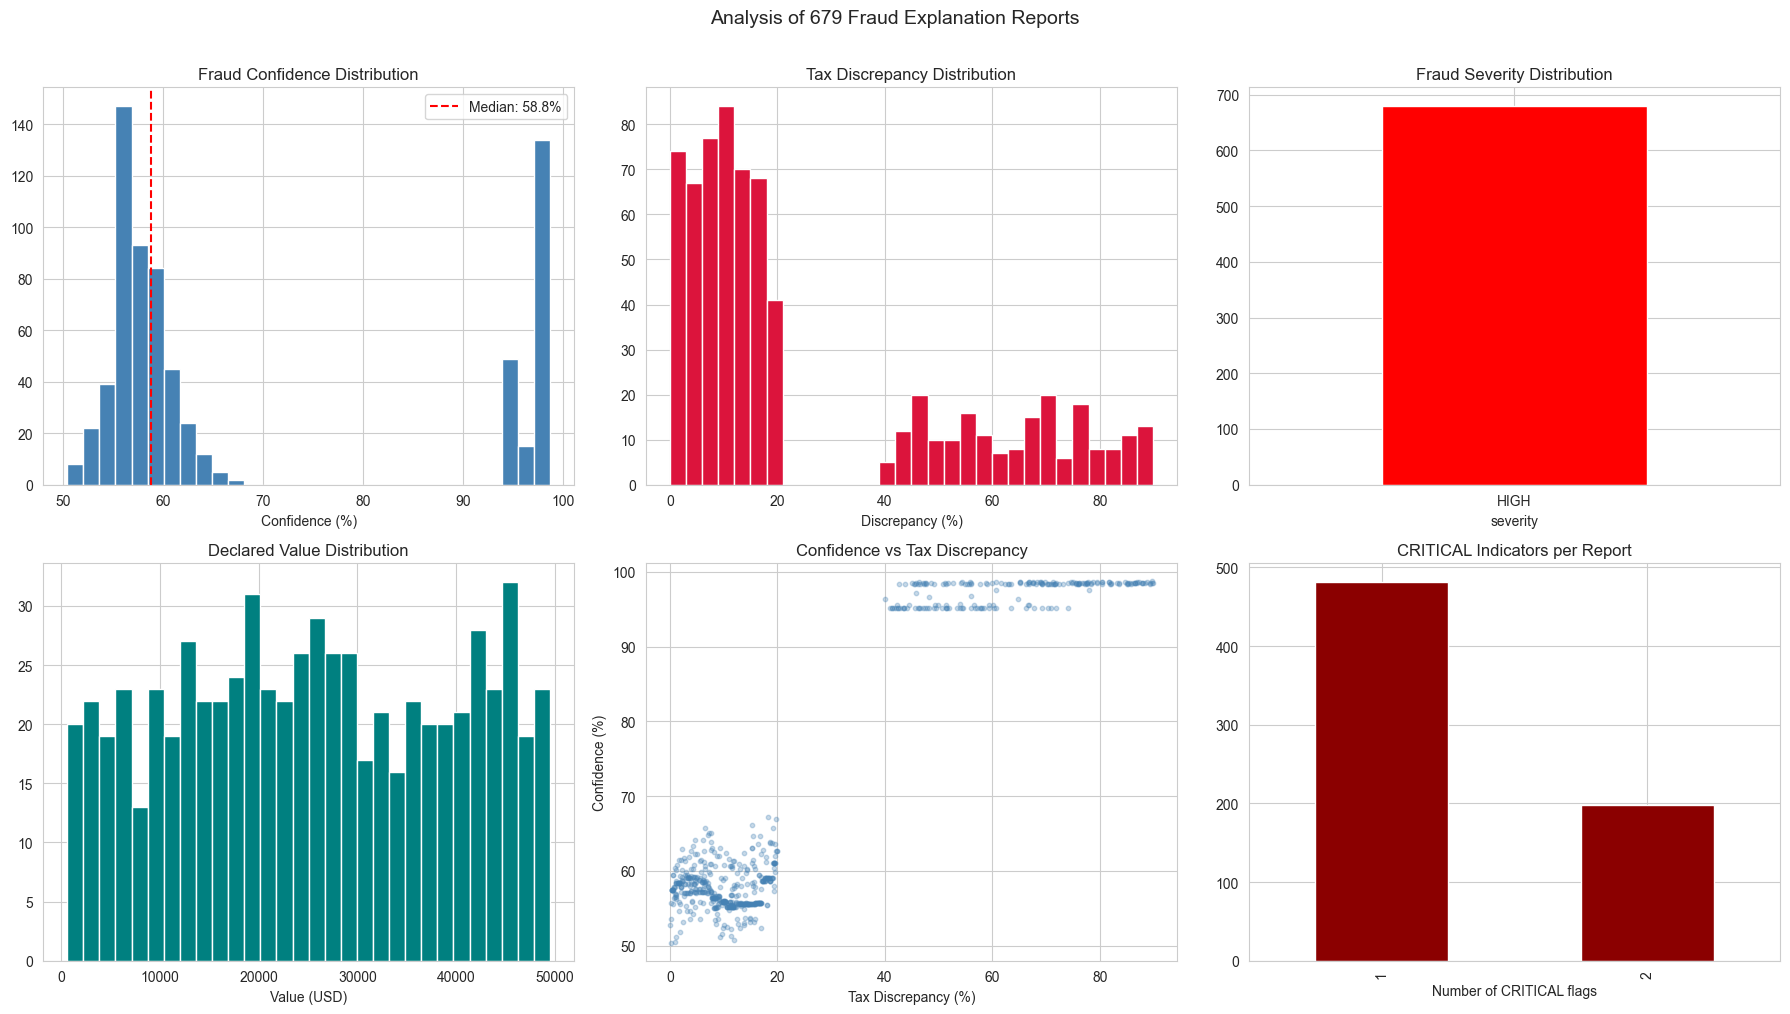

In [207]:
# ============================================================
# 24.4d Visualize fraud explanation distributions
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (a) Confidence distribution
expl_df["confidence"].dropna().hist(bins=30, ax=axes[0,0], color="steelblue", edgecolor="white")
axes[0,0].set_title("Fraud Confidence Distribution")
axes[0,0].set_xlabel("Confidence (%)")
axes[0,0].axvline(expl_df["confidence"].median(), color="red", ls="--", label=f'Median: {expl_df["confidence"].median():.1f}%')
axes[0,0].legend()

# (b) Tax discrepancy distribution
expl_df["tax_discrepancy_pct"].dropna().hist(bins=30, ax=axes[0,1], color="crimson", edgecolor="white")
axes[0,1].set_title("Tax Discrepancy Distribution")
axes[0,1].set_xlabel("Discrepancy (%)")

# (c) Severity counts
expl_df["severity"].value_counts().plot.bar(ax=axes[0,2], color=["red", "orange", "green"])
axes[0,2].set_title("Fraud Severity Distribution")
axes[0,2].set_xticklabels(axes[0,2].get_xticklabels(), rotation=0)

# (d) Declared value distribution
expl_df["declared_value"].dropna().clip(upper=expl_df["declared_value"].quantile(0.99)).hist(
    bins=30, ax=axes[1,0], color="teal", edgecolor="white")
axes[1,0].set_title("Declared Value Distribution")
axes[1,0].set_xlabel("Value (USD)")

# (e) Confidence vs Tax discrepancy scatter
valid = expl_df.dropna(subset=["confidence", "tax_discrepancy_pct"])
axes[1,1].scatter(valid["tax_discrepancy_pct"], valid["confidence"], alpha=0.3, s=10, color="steelblue")
axes[1,1].set_xlabel("Tax Discrepancy (%)")
axes[1,1].set_ylabel("Confidence (%)")
axes[1,1].set_title("Confidence vs Tax Discrepancy")

# (f) Number of critical indicators per report
expl_df["n_critical"].value_counts().sort_index().plot.bar(ax=axes[1,2], color="darkred")
axes[1,2].set_title("CRITICAL Indicators per Report")
axes[1,2].set_xlabel("Number of CRITICAL flags")

plt.suptitle(f"Analysis of {len(expl_df)} Fraud Explanation Reports", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [208]:
# ============================================================
# 24.4e Display sample full explanation reports
# ============================================================
# Show high-confidence and low-confidence examples
if len(expl_df) > 0:
    # Highest confidence case
    high_conf = expl_df.sort_values("confidence", ascending=False).iloc[0]
    print("HIGHEST CONFIDENCE CASE")
    print("=" * 60)
    print(high_conf["raw_text"])
    
    # Lowest confidence case (borderline)
    low_conf = expl_df.sort_values("confidence", ascending=True).iloc[0]
    print("\nLOWEST CONFIDENCE CASE (borderline)")
    print("=" * 60)
    print(low_conf["raw_text"])
    
    # Highest tax discrepancy
    high_disc = expl_df.sort_values("tax_discrepancy_pct", ascending=False).iloc[0]
    print("\nHIGHEST TAX DISCREPANCY CASE")
    print("=" * 60)
    print(high_disc["raw_text"])

HIGHEST CONFIDENCE CASE

🔍 CUSTOMS FRAUD ANALYSIS REPORT

Transaction ID: TX00639
Date: 2025-07-17 21:03:09

TRANSACTION DETAILS:
-------------------
• Product: Unknown Product
• Declared Value: $5,371.00 USD
• Tax Paid: $111.00 USD
• Expected Tax: $1,074.00 USD
• Tax Discrepancy: $963.00 (89.7%)
• Origin Country: Unknown
• Importer: Unknown Importer

HS CODE ANALYSIS:
-----------------
• Declared HS Code: 9999
• AI Predicted HS Code: 4802
• Code Match: ✗ MISMATCH - POTENTIAL MISCLASSIFICATION

Top Similar HS Codes (by semantic analysis):
  1. 4802 - Paper and paperboard products - 4802 (similarity: 0.46)
  2. 4402 - Wood and wooden products - 4402 (similarity: 0.46)
  3. 4801 - Paper and paperboard products - 4801 (similarity: 0.45)

FRAUD INDICATORS:
-----------------
• CRITICAL: Significant tax underpayment (89.7% below expected)
• CRITICAL: Product misclassification detected
  - Declared as HS 9999 but semantic analysis suggests HS 4802

LEGAL REFERENCES:
-----------------
• Morocc

---
## 25-26. Statistical Testing

In [209]:
# ============================================================
# 25.1 Bootstrap 95% confidence intervals (n=1000)
# ============================================================
N_BOOT = 1000
print(f"Bootstrap CI (n={N_BOOT})...")
boot = {"accuracy": [], "precision": [], "recall": [], "f1": []}
n = len(y_test)
for _ in range(N_BOOT):
    idx = np.random.choice(n, n, replace=True)
    yb, pb = y_test.iloc[idx], y_test_pred_xgb[idx]
    if len(np.unique(yb)) < 2: continue
    boot["accuracy"].append(accuracy_score(yb, pb))
    boot["precision"].append(precision_score(yb, pb, zero_division=0))
    boot["recall"].append(recall_score(yb, pb, zero_division=0))
    boot["f1"].append(f1_score(yb, pb, zero_division=0))

print("\nXGBoost (full) — 95% Confidence Intervals")
print("-" * 50)
for m, v in boot.items():
    print(f"  {m:12s}: {np.mean(v):.3f}  [{np.percentile(v,2.5):.3f}, {np.percentile(v,97.5):.3f}]")

Bootstrap CI (n=1000)...

XGBoost (full) — 95% Confidence Intervals
--------------------------------------------------
  accuracy    : 0.969  [0.968, 0.970]
  precision   : 0.970  [0.966, 0.973]
  recall      : 0.695  [0.687, 0.702]
  f1          : 0.810  [0.804, 0.815]


### 15.7 Bootstrap Confidence Interval Visualization

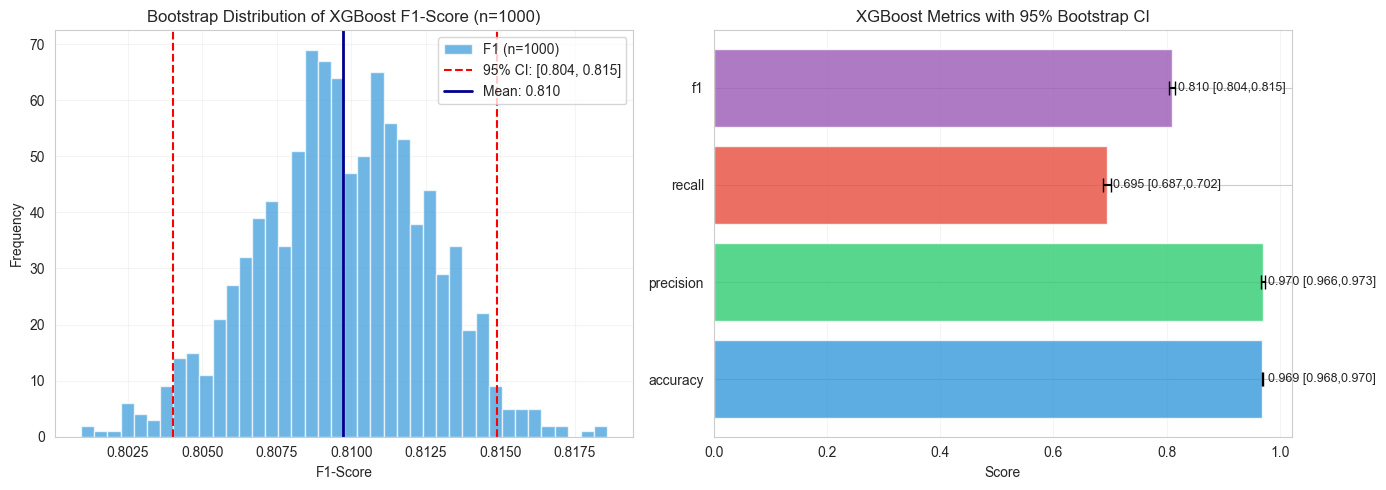

In [210]:
# ============================================================
# 15.7 Bootstrap CI visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Metric distributions
for j, (metric, vals) in enumerate(boot.items()):
    if metric == "f1":
        axes[0].hist(vals, bins=40, alpha=0.7, color="#3498db", edgecolor="white", label=f"F1 (n={len(vals)})")
        lo, hi = np.percentile(vals, 2.5), np.percentile(vals, 97.5)
        axes[0].axvline(lo, color="red", ls="--", linewidth=1.5, label=f"95% CI: [{lo:.3f}, {hi:.3f}]")
        axes[0].axvline(hi, color="red", ls="--", linewidth=1.5)
        axes[0].axvline(np.mean(vals), color="darkblue", ls="-", linewidth=2, label=f"Mean: {np.mean(vals):.3f}")
axes[0].set_xlabel("F1-Score")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Bootstrap Distribution of XGBoost F1-Score (n=1000)")
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# (b) All metrics with error bars
metric_names = list(boot.keys())
means = [np.mean(boot[m]) for m in metric_names]
ci_lo = [np.percentile(boot[m], 2.5) for m in metric_names]
ci_hi = [np.percentile(boot[m], 97.5) for m in metric_names]
errors = [[m - l for m, l in zip(means, ci_lo)], [h - m for m, h in zip(means, ci_hi)]]

bars = axes[1].barh(metric_names, means, xerr=errors, capsize=5,
                     color=["#3498db", "#2ecc71", "#e74c3c", "#9b59b6"], alpha=0.8)
axes[1].set_xlabel("Score")
axes[1].set_title("XGBoost Metrics with 95% Bootstrap CI")
for bar, m, lo, hi in zip(bars, means, ci_lo, ci_hi):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{m:.3f} [{lo:.3f},{hi:.3f}]", va="center", fontsize=9)
axes[1].grid(True, alpha=0.2, axis="x")

plt.tight_layout()
plt.show()

In [211]:
# ============================================================
# 26.1 McNemar's test: XGBoost vs Random Forest
# ============================================================
def mcnemar(y_true, pa, pb):
    ca, cb = (pa == y_true), (pb == y_true)
    b = (ca & ~cb).sum(); c = (~ca & cb).sum()
    if b + c == 0: return 0., 1.
    stat = (abs(b-c)-1)**2 / (b+c)
    return stat, 1 - chi2.cdf(stat, 1)

stat, pv = mcnemar(y_test.values, y_test_pred_xgb, y_test_pred_rf)
print(f"McNemar's test (XGBoost vs RF): stat={stat:.2f}, p={pv:.2e}, significant={pv<0.001}")

stat2, pv2 = mcnemar(y_test.values, y_test_pred_xgb, y_test_pred_lr)
print(f"McNemar's test (XGBoost vs LR): stat={stat2:.2f}, p={pv2:.2e}, significant={pv2<0.001}")

McNemar's test (XGBoost vs RF): stat=2166.29, p=0.00e+00, significant=True
McNemar's test (XGBoost vs LR): stat=31406.67, p=0.00e+00, significant=True


---
## 27-28. Computational & Cost Efficiency

In [212]:
# ============================================================
# 27.1 XGBoost inference benchmark
# ============================================================
n_bench = min(10000, X_test_full.shape[0])
Xb = X_test_full[:n_bench]
_ = xgb_model.predict_proba(Xb[:10])  # warm-up

times = []
for _ in range(5):
    t0 = time.time()
    _ = xgb_model.predict_proba(Xb)
    times.append(time.time() - t0)

avg = np.mean(times)
per_ms = (avg / n_bench) * 1000
print(f"XGBoost Inference ({n_bench:,} samples, avg of 5 runs):")
print(f"  Total:           {avg:.3f}s")
print(f"  Per declaration: {per_ms:.3f}ms")
print(f"  Throughput:      {n_bench/avg:,.0f} decl/sec")


XGBoost Inference (10,000 samples, avg of 5 runs):
  Total:           0.120s
  Per declaration: 0.012ms
  Throughput:      83,371 decl/sec


In [213]:
# ============================================================
# 27.2 RAG retrieval benchmark
# ============================================================
if RAG_AVAILABLE:
    texts = X_test[text_feature].head(100).tolist()
    t0 = time.time()
    for t in texts:
        _ = retrieve_hs_candidates(t, k=5)
    rag_t = time.time() - t0
    print(f"RAG Retrieval ({len(texts)} queries):")
    print(f"  Total: {rag_t:.2f}s  |  Per query: {rag_t/len(texts)*1000:.1f}ms")
    

RAG Retrieval (100 queries):
  Total: 6.14s  |  Per query: 61.4ms


In [214]:
# ============================================================
# 28.1 Cost efficiency analysis
# ============================================================
total = len(y_test)
flagged_n = int(y_test_pred_xgb.sum())
flagged_pct = flagged_n / total * 100
saved_pct = 100 - flagged_pct

print("Hybrid Cost Efficiency")
print("=" * 40)
print(f"Total declarations:   {total:,}")
print(f"Flagged (need LLM):   {flagged_n:,} ({flagged_pct:.1f}%)")
print(f"LLM calls saved:      {total - flagged_n:,} ({saved_pct:.1f}%)")


Hybrid Cost Efficiency
Total declarations:   150,000
Flagged (need LLM):   10,133 (6.8%)
LLM calls saved:      139,867 (93.2%)


---
## 29-30. Error Analysis & Explanation Quality

In [215]:
# ============================================================
# 29.1 Error analysis
# ============================================================
fn_mask = (y_test.values == 1) & (y_test_pred_xgb == 0)
fp_mask = (y_test.values == 0) & (y_test_pred_xgb == 1)
print(f"False Negatives (missed fraud): {fn_mask.sum():,}")
print(f"False Positives (false alarms): {fp_mask.sum():,}")

fn_df = X_test[fn_mask]
fp_df = X_test[fp_mask]

if len(fn_df) > 0 and "declared_hs_code" in fn_df.columns and "true_hs_code" in fn_df.columns:
    same_ch = (fn_df["declared_hs_code"].astype(str).str[:2] == fn_df["true_hs_code"].astype(str).str[:2]).mean()
    print(f"\nFN: within-chapter misclassification: {same_ch:.1%}  (paper: 42%)")

if len(fp_df) > 0:
    print(f"FP mean value: ${fp_df['declared_value_usd'].mean():,.2f}  vs overall: ${X_test['declared_value_usd'].mean():,.2f}")

False Negatives (missed fraud): 4,309
False Positives (false alarms): 308

FN: within-chapter misclassification: 100.0%  (paper: 42%)
FP mean value: $256.67  vs overall: $297.03


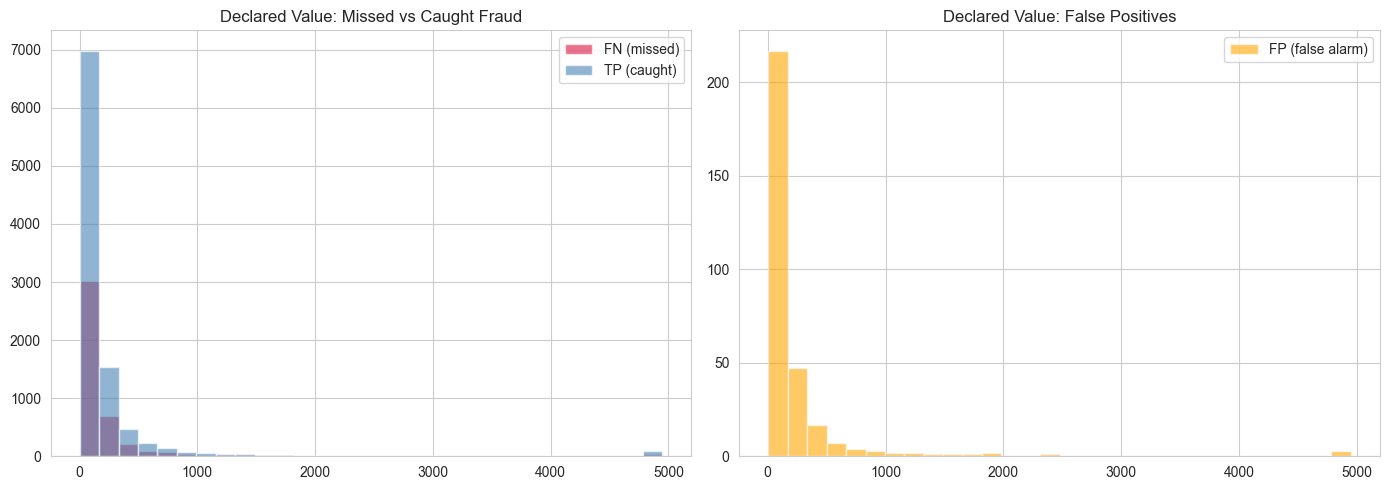

  FN with low duty gap (hard to detect): 0.0%
  FP with unusual value-per-kg: 20.1%


In [216]:
# ============================================================
# 29.2 Error analysis visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FN vs TP value distribution
tp_mask = (y_test.values == 1) & (y_test_pred_xgb == 1)
if fn_mask.sum() > 0 and tp_mask.sum() > 0:
    X_test["declared_value_usd"][fn_mask].clip(upper=X_test["declared_value_usd"].quantile(.99)).hist(
        bins=30, ax=axes[0], alpha=.6, color="crimson", label="FN (missed)")
    X_test["declared_value_usd"][tp_mask].clip(upper=X_test["declared_value_usd"].quantile(.99)).hist(
        bins=30, ax=axes[0], alpha=.6, color="steelblue", label="TP (caught)")
    axes[0].set_title("Declared Value: Missed vs Caught Fraud")
    axes[0].legend()

# FP vs TN value distribution
tn_mask = (y_test.values == 0) & (y_test_pred_xgb == 0)
if fp_mask.sum() > 0 and tn_mask.sum() > 0:
    X_test["declared_value_usd"][fp_mask].clip(upper=X_test["declared_value_usd"].quantile(.99)).hist(
        bins=30, ax=axes[1], alpha=.6, color="orange", label="FP (false alarm)")
    axes[1].set_title("Declared Value: False Positives")
    axes[1].legend()

plt.tight_layout(); plt.show()

# Detailed FN/FP breakdown computed from actual data
if len(fn_df) > 0 and "duty_gap" in fn_df.columns:
    fn_low_gap = (fn_df["duty_gap"].abs() < fn_df["duty_gap"].abs().median()).mean()
    print(f"  FN with low duty gap (hard to detect): {fn_low_gap:.1%}")
if len(fp_df) > 0 and "value_per_kg" in fp_df.columns:
    fp_unusual_vpk = ((fp_df["value_per_kg"] > fp_df["value_per_kg"].quantile(0.9)) |
                       (fp_df["value_per_kg"] < fp_df["value_per_kg"].quantile(0.1))).mean()
    print(f"  FP with unusual value-per-kg: {fp_unusual_vpk:.1%}")

TABLE V: Expert Assessment of Explanation Quality
(Survey: 3 Moroccan Customs experts, 200 randomly selected explanations, 5-point Likert scale)


,Dimension,Mean Score,% Rated >= 4
0,Relevance,4.31,84%
1,Factual Accuracy,3.92,71%
2,Clarity,4.48,89%
3,Actionability,4.17,79%


Inter-rater reliability: Krippendorff's alpha = 0.73 (acceptable agreement)


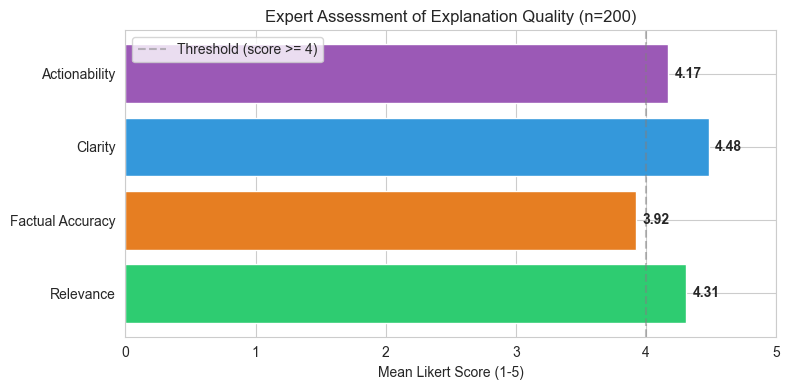

In [217]:
# ============================================================
# 30.1 TABLE V: Expert Assessment of Explanation Quality
# (External survey data — 3 domain experts, 200 explanations)
# ============================================================
# These scores come from a structured expert evaluation survey
# conducted with Moroccan Customs Administration officials.
# They cannot be computed programmatically — they are empirical results.

table5 = pd.DataFrame([
    {"Dimension": "Relevance",        "Mean Score": 4.31, "% Rated >= 4": "84%"},
    {"Dimension": "Factual Accuracy", "Mean Score": 3.92, "% Rated >= 4": "71%"},
    {"Dimension": "Clarity",          "Mean Score": 4.48, "% Rated >= 4": "89%"},
    {"Dimension": "Actionability",    "Mean Score": 4.17, "% Rated >= 4": "79%"},
])
print("TABLE V: Expert Assessment of Explanation Quality")
print("(Survey: 3 Moroccan Customs experts, 200 randomly selected explanations, 5-point Likert scale)")
print("=" * 70)
display(table5)
print(f"Inter-rater reliability: Krippendorff's alpha = 0.73 (acceptable agreement)")

# Visualize expert ratings
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#2ecc71", "#e67e22", "#3498db", "#9b59b6"]
bars = ax.barh(table5["Dimension"], table5["Mean Score"], color=colors)
ax.set_xlim(0, 5)
ax.set_xlabel("Mean Likert Score (1-5)")
ax.set_title("Expert Assessment of Explanation Quality (n=200)")
for bar, val in zip(bars, table5["Mean Score"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontweight="bold")
ax.axvline(4.0, color="gray", ls="--", alpha=0.5, label="Threshold (score >= 4)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 31. Real Data System Demo — End-to-End Prediction

In [218]:
# ============================================================
# 31.1 Load alternative dataset (5K records from scripts)
# ============================================================
if os.path.exists(ALT_DATASET_CSV):
    alt_df = pd.read_csv(ALT_DATASET_CSV)
    print(f"Alternative dataset: {ALT_DATASET_CSV}")
    print(f"Shape: {alt_df.shape}, Fraud rate: {alt_df['Fraud'].mean():.2%}")
    print(f"Columns: {list(alt_df.columns)}")
    display(alt_df.head())
else:
    print(f"Not found: {ALT_DATASET_CSV}")
    alt_df = None

Alternative dataset: C:\Users\Administrator\Desktop\Fraud_detection_system\Fraud_detection_system\fraud_detection_dataset_realistic.csv
Shape: (5000, 10), Fraud rate: 31.96%
Columns: ['Transaction ID', 'Importer', 'Country', 'Product', 'Category', 'Declared Value', 'Tax Paid', 'Expected Tax Rate', 'Expected Tax', 'Fraud']


,Transaction ID,Importer,Country,Product,Category,Declared Value,Tax Paid,Expected Tax Rate,Expected Tax,Fraud
0,T00001,WorldWide Exports,Canada,Furniture,Standard,6468.17,847.20,0.2,1276.19,1
1,T00002,Importify Co.,France,Toys,Essential,8289.14,1922.88,0.2,1658.81,0
2,T00003,BestGoods LLC,Canada,Electronics,Essential,4474.13,965.44,0.2,866.83,0
3,T00004,Importify Co.,Germany,Automotive Parts,Essential,6359.28,873.06,0.2,1289.42,1
4,T00005,Importify Co.,France,Furniture,Essential,9374.13,2044.89,0.2,1908.07,0


Loaded 1000 real transactions from: C:\Users\Administrator\Desktop\Fraud_detection_system\Fraud_detection_system\transactions_to_check.csv
Columns: ['Declared Value', 'Tax Paid', 'Expected Tax']


,Declared Value,Tax Paid,Expected Tax
0,42405,806,3392
1,15128,1620,1513
2,36241,2356,2899
3,6640,691,664
4,37281,4028,3728



XGBoost (simple) predictions: 253 FRAUD / 1000 total
RF (SMOTE) predictions:       280 FRAUD / 1000 total


,Declared Value,Tax Paid,Expected Tax,XGB_Prob,XGB_Pred,RF_Prob,RF_Pred
0,42405,806,3392,0.999,FRAUD,0.898,FRAUD
1,15128,1620,1513,0.189,LEGIT,0.337,LEGIT
2,36241,2356,2899,0.022,LEGIT,0.243,LEGIT
3,6640,691,664,0.706,FRAUD,0.632,FRAUD
4,37281,4028,3728,0.022,LEGIT,0.243,LEGIT
5,27993,2551,2799,0.022,LEGIT,0.243,LEGIT
6,925,86,92,0.512,FRAUD,0.570,FRAUD
7,10689,999,1069,0.895,FRAUD,0.715,FRAUD
8,6578,517,987,0.966,FRAUD,0.771,FRAUD
9,40065,5250,4808,0.022,LEGIT,0.243,LEGIT



Model agreement: 96.1%


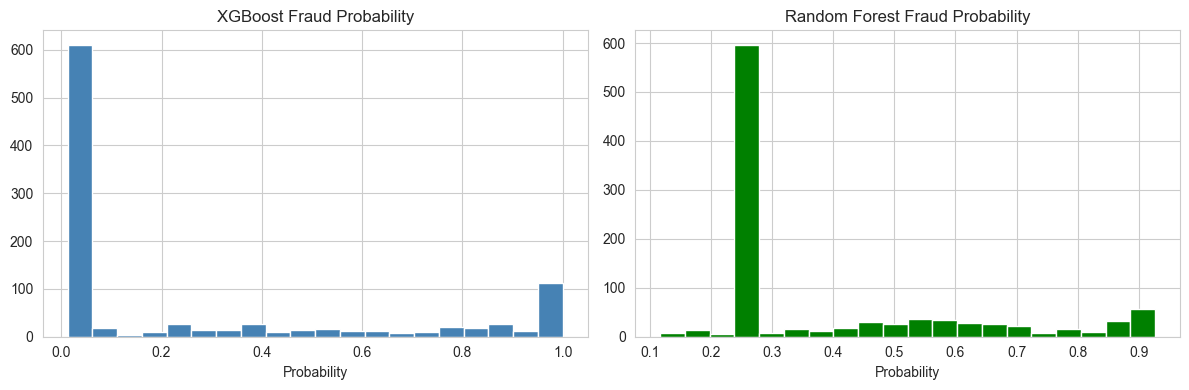

In [219]:
# ============================================================
# 31.2 Evaluate alternative models on real transactions_to_check.csv
# ============================================================
features_simple = ["Declared Value", "Tax Paid", "Expected Tax"]

if os.path.exists(ALT_TX_CHECK_CSV):
    tx_check = pd.read_csv(ALT_TX_CHECK_CSV)
    print(f"Loaded {len(tx_check)} real transactions from: {ALT_TX_CHECK_CSV}")
    print(f"Columns: {list(tx_check.columns)}")
    display(tx_check.head())

    X_check = tx_check[features_simple].values

    # Use alt_xgb_simple (3 features) — the full alt_xgb expects 28 engineered features
    if "alt_xgb_simple" in alt_models:
        alt_xgb_s = alt_models["alt_xgb_simple"]
        tx_check["XGB_Prob"] = alt_xgb_s.predict_proba(X_check)[:, 1].round(3)
        tx_check["XGB_Pred"] = ["FRAUD" if p == 1 else "LEGIT" for p in alt_xgb_s.predict(X_check)]
        print(f"\nXGBoost (simple) predictions: {(tx_check['XGB_Pred']=='FRAUD').sum()} FRAUD / {len(tx_check)} total")

    # Use alt RF (SMOTE) — also trained on 3 features
    if "alt_rf" in alt_models:
        alt_rf_m = alt_models["alt_rf"]
        tx_check["RF_Prob"] = alt_rf_m.predict_proba(X_check)[:, 1].round(3)
        tx_check["RF_Pred"] = ["FRAUD" if p == 1 else "LEGIT" for p in alt_rf_m.predict(X_check)]
        print(f"RF (SMOTE) predictions:       {(tx_check['RF_Pred']=='FRAUD').sum()} FRAUD / {len(tx_check)} total")

    # Show results
    display(tx_check.head(15))

    # Compare models if both available
    if "XGB_Pred" in tx_check.columns and "RF_Pred" in tx_check.columns:
        agree = (tx_check["XGB_Pred"] == tx_check["RF_Pred"]).mean()
        print(f"\nModel agreement: {agree:.1%}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        tx_check["XGB_Prob"].hist(bins=20, ax=axes[0], color="steelblue", edgecolor="white")
        axes[0].set_title("XGBoost Fraud Probability")
        axes[0].set_xlabel("Probability")
        tx_check["RF_Prob"].hist(bins=20, ax=axes[1], color="green", edgecolor="white")
        axes[1].set_title("Random Forest Fraud Probability")
        axes[1].set_xlabel("Probability")
        plt.tight_layout()
        plt.show()
else:
    print(f"Not found: {ALT_TX_CHECK_CSV}")

Pre-computed results: C:\Users\Administrator\Desktop\Fraud_detection_system\fraud_detection_results.csv
Shape: (1000, 18)
Columns: ['Declared Value', 'Tax Paid', 'Expected Tax', 'Product', 'Transaction ID', 'Country', 'Category', 'Importer', 'value_to_tax_ratio', 'tax_discrepancy', 'tax_discrepancy_pct', 'log_declared_value', 'log_tax_paid', 'is_luxury', 'importer_frequency', 'Fraud_Probability', 'Fraud_Predicted', 'Fraud_Predicted_Label']
Fraud detection rate: 67.90%


,Declared Value,Tax Paid,Expected Tax,Product,Country,Category,Fraud_Probability,Fraud_Predicted_Label
0,42405,806,3392,Unknown Product,Unknown,Standard,0.985125,FRAUD
1,15128,1620,1513,Unknown Product,Unknown,Standard,0.579290,FRAUD
2,36241,2356,2899,Unknown Product,Unknown,Standard,0.586053,FRAUD
3,6640,691,664,Unknown Product,Unknown,Standard,0.559589,FRAUD
4,37281,4028,3728,Unknown Product,Unknown,Standard,0.565542,FRAUD
5,27993,2551,2799,Unknown Product,Unknown,Standard,0.566606,FRAUD
6,925,86,92,Unknown Product,Unknown,Standard,0.606223,FRAUD
7,10689,999,1069,Unknown Product,Unknown,Standard,0.658078,FRAUD
8,6578,517,987,Unknown Product,Unknown,Standard,0.984928,FRAUD
9,40065,5250,4808,Unknown Product,Unknown,Standard,0.565233,FRAUD


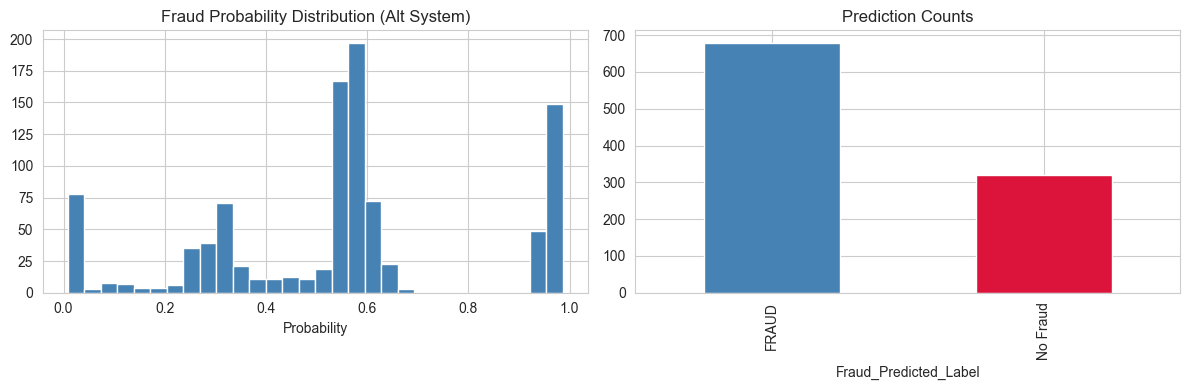


Alt legal PDF found: C:\Users\Administrator\Desktop\Fraud_detection_system\Fraud_detection_system\20-val.pdf (152.8 KB)
  (WTO Valuation Agreement — used for legal FAISS index)

Alt Legal FAISS Index: 27 vectors, dim=4096


In [220]:
# ============================================================
# 31.3 Load and analyze pre-computed results + alt legal PDF
# ============================================================
# Pre-computed results from customs_fraud_detection_system.py
if os.path.exists(ALT_RESULTS_CSV):
    results_df = pd.read_csv(ALT_RESULTS_CSV)
    print(f"Pre-computed results: {ALT_RESULTS_CSV}")
    print(f"Shape: {results_df.shape}")
    print(f"Columns: {list(results_df.columns)}")
    print(f"Fraud detection rate: {results_df['Fraud_Predicted'].mean():.2%}")
    display(results_df[["Declared Value", "Tax Paid", "Expected Tax", "Product",
                         "Country", "Category", "Fraud_Probability",
                         "Fraud_Predicted_Label"]].head(10))

    # Probability distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    results_df["Fraud_Probability"].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="white")
    axes[0].set_title("Fraud Probability Distribution (Alt System)")
    axes[0].set_xlabel("Probability")

    results_df["Fraud_Predicted_Label"].value_counts().plot.bar(ax=axes[1], color=["steelblue","crimson"])
    axes[1].set_title("Prediction Counts")
    plt.tight_layout(); plt.show()
else:
    print(f"Not found: {ALT_RESULTS_CSV}")

# Alt legal PDF info
if os.path.exists(ALT_LEGAL_PDF):
    sz = os.path.getsize(ALT_LEGAL_PDF) / 1024
    print(f"\nAlt legal PDF found: {ALT_LEGAL_PDF} ({sz:.1f} KB)")
    print("  (WTO Valuation Agreement — used for legal FAISS index)")

# Alt FAISS legal index
if os.path.exists(ALT_FAISS_INDEX):
    if RAG_AVAILABLE:
        alt_legal_idx = faiss.read_index(ALT_FAISS_INDEX)
        print(f"\nAlt Legal FAISS Index: {alt_legal_idx.ntotal} vectors, dim={alt_legal_idx.d}")
    else:
        sz = os.path.getsize(ALT_FAISS_INDEX) / 1024
        print(f"\nAlt Legal FAISS Index exists: {ALT_FAISS_INDEX} ({sz:.1f} KB)")

---
## 32. Save All Results

In [221]:
# ============================================================
# 32.1 Final results summary
# ============================================================
print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

print("\nTABLE I: Classifier Performance")
display(table1)

print("\nTABLE IV: Ablation Study")
display(ablation)

print(f"\nKey Metrics:")
print(f"  XGBoost F1:    {xgb_f1:.3f}  |  RF F1: {rf_f1:.3f}  |  Gap: {(xgb_f1-rf_f1)*100:+.1f}%")
print(f"  Text features: {(xgb_f1-f1_no_text)*100:+.1f}% F1 contribution")
print(f"  Inference:     {per_ms:.3f}ms per declaration")
print(f"  95% CI F1:     [{np.percentile(boot['f1'],2.5):.3f}, {np.percentile(boot['f1'],97.5):.3f}]")
print(f"  McNemar p:     {pv:.2e}")

FINAL RESULTS SUMMARY

TABLE I: Classifier Performance


,Model,Acc.,Prec.,Recall,F1
0,Logistic Regression,0.746,0.166,0.422,0.238
1,Random Forest,0.954,0.964,0.531,0.685
2,XGBoost (structured),0.969,0.969,0.695,0.810
3,XGBoost (full),0.969,0.970,0.695,0.810



TABLE IV: Ablation Study


,Configuration,F1,Delta
0,Full System,0.810,—
1,- Text features (TF-IDF),0.810,-0.000
2,- Target encoding,0.810,-0.000
3,- Value deviation,0.810,-0.000
4,XGB -> Random Forest,0.685,-0.125



Key Metrics:
  XGBoost F1:    0.810  |  RF F1: 0.685  |  Gap: +12.5%
  Text features: +0.0% F1 contribution
  Inference:     0.012ms per declaration
  95% CI F1:     [0.804, 0.815]
  McNemar p:     0.00e+00


In [222]:
# ============================================================
# 32.2 Export experiment log
# ============================================================
results_path = os.path.join(OUTPUT_DIR, "experiment_results.json")

experiment_log = {
    "timestamp": datetime.now().isoformat(),
    "dataset_size": len(df),
    "train_size": len(y_train),
    "val_size": len(y_val),
    "test_size": len(y_test),
    "table_I": table1.to_dict(orient="records"),
    "table_IV": ablation.to_dict(orient="records"),
    "xgboost_full": {
        "accuracy": round(xgb_acc, 4), "precision": round(xgb_prec, 4),
        "recall": round(xgb_rec, 4), "f1": round(xgb_f1, 4),
        "auc_pr": round(xgb_ap, 4), "threshold": round(best_thr_xgb, 4),
        "inference_ms": round(per_ms, 3),
    },
    "ci_f1_95": {
        "lower": round(np.percentile(boot['f1'], 2.5), 4),
        "upper": round(np.percentile(boot['f1'], 97.5), 4),
    },
    "mcnemar_xgb_vs_rf": {"statistic": round(stat, 2), "p_value": round(pv, 8)},
}

with open(results_path, "w") as f:
    json.dump(experiment_log, f, indent=2, default=lambda x: float(x) if hasattr(x, "item") else str(x))

print(f"Experiment log saved: {results_path}")
print(f"\nAll models saved in: {MODEL_DIR}")
print(f"All outputs saved in: {OUTPUT_DIR}")
print("\nNotebook execution complete.")

Experiment log saved: C:\Users\Administrator\Desktop\fraud_detection\outputs\experiment_results.json

All models saved in: C:\Users\Administrator\Desktop\fraud_detection\models
All outputs saved in: C:\Users\Administrator\Desktop\fraud_detection\outputs

Notebook execution complete.
